# Lab Day 2 — Backbone, công thức huấn luyện và suy luận trên DeepWeeds

Notebook **khung** cho Colab hoặc Kaggle. Các ô có chữ `TODO` là phần **bạn tự viết**; ô cài đặt, tải dữ liệu
và chạy `eval.py` đã viết sẵn. Đọc `README.md` (quy tắc chia dữ liệu, cách đánh giá), `GUIDE.md` và `RUBRIC.md` trước.

**Quy tắc quan trọng nhất:** chọn mọi thứ trên **val**; **test chỉ chạy một lần mỗi seed ở Bước 4**.

Bản đồ: Bước 0 (EDA, kiểm tra) → Bước 1 (backbone) → Bước 2 (công thức huấn luyện) → Bước 3 (suy luận)
→ Bước 4 (chung kết + `eval.py`) → Bước 5 (xlsx, biểu đồ, báo cáo).

## 0. Cài đặt môi trường

In [1]:
# Cài thư viện (Colab/Kaggle). Kaggle: bật Internet trong Settings.
!pip -q install timm openpyxl scikit-learn

import sys, os, platform
# Số worker DataLoader theo số nhân CPU (Colab/Kaggle: 2; máy thuê nhiều nhân: tới 12). Chỉ ảnh hưởng tốc độ.
os.environ.setdefault("NUM_WORKERS", str(max(2, min(12, (os.cpu_count() or 2) - 2))))
import numpy as np, pandas as pd, torch, timm

# Colab/Kaggle: repo đã `git clone` vào thư mục hiện tại. Máy cá nhân: kernel chạy từ submissions/<...>/code/.
REPO_URL = "https://github.com/tam253211-a11y/K4-Track4-Day2-DangHuuTam-2A202602940-Deeplearning-Advance.git"
REPO_DIR = "K4-Track4-Day2-DangHuuTam-2A202602940-Deeplearning-Advance"
if os.path.exists("eval.py"):                # chạy lại ô này trong cùng phiên: đã đứng ở gốc repo
    REPO_DIR = "."
elif not os.path.exists(f"{REPO_DIR}/eval.py") and os.path.exists("../../../eval.py"):
    REPO_DIR = "../../.."
if not os.path.exists(f"{REPO_DIR}/eval.py"):    # Colab/Kaggle mở notebook lẻ: clone repo về
    !git clone -q {REPO_URL} {REPO_DIR}
assert os.path.exists(f"{REPO_DIR}/eval.py"), "Không tìm thấy gốc repo, sửa REPO_DIR"
os.chdir(REPO_DIR)                           # từ đây mọi đường dẫn (data/, predictions/...) tính từ gốc repo
REPO_DIR = os.getcwd()
CODE_DIR = f"{REPO_DIR}/submissions/2A202602940_dang_huu_tam/code"
sys.path.insert(0, REPO_DIR)                 # để import eval.py
sys.path.insert(0, CODE_DIR)                 # code/ đã chép từ starter/

print("python", platform.python_version(), "| torch", torch.__version__, "| timm", timm.__version__)
print("NUM_WORKERS:", os.environ["NUM_WORKERS"], "| CPU:", os.cpu_count())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "KHÔNG CÓ GPU")

python 3.12.14 | torch 2.11.0+cu128 | timm 1.0.30
NUM_WORKERS: 12 | CPU: 54
GPU: NVIDIA GeForce RTX 4090


### Tải dữ liệu (đã viết sẵn)
Ảnh từ Zenodo (~490 MB, kiểm tra MD5), nhãn và các file chia fold từ GitHub của tác giả.
**Sau khi giải nén, hãy `ls` để xem ảnh nằm ở thư mục nào** rồi đặt `IMAGES_DIR` cho đúng.

In [2]:
import hashlib, zipfile, urllib.request

# Tải bằng Python (không cần wget/unzip, chạy được trên Colab, Kaggle và máy thuê)
os.makedirs("data/labels", exist_ok=True)
if not os.path.exists("data/images.zip"):
    urllib.request.urlretrieve("https://zenodo.org/records/7939060/files/images.zip?download=1", "data/images.zip")

h = hashlib.md5()
with open("data/images.zip", "rb") as f:
    for chunk in iter(lambda: f.read(1 << 20), b""):
        h.update(chunk)
assert h.hexdigest() == "b7b30f96d466fba86016aa5a26606e0f", f"MD5 sai: {h.hexdigest()}"

os.makedirs("data/images", exist_ok=True)            # zip không có thư mục con: .jpg nằm thẳng trong data/images/
with zipfile.ZipFile("data/images.zip") as z:
    todo = [n for n in z.namelist() if not os.path.exists(f"data/images/{n}")]
    for n in todo:
        z.extract(n, "data/images")
imgs = sorted(os.listdir("data/images"))
print(imgs[:3], len(imgs), "ảnh")

BASE = "https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels"
for name in ["labels", "train_subset0", "val_subset0", "test_subset0"]:
    urllib.request.urlretrieve(f"{BASE}/{name}.csv", f"data/labels/{name}.csv")
print({f: os.path.getsize(f"data/labels/{f}") for f in sorted(os.listdir("data/labels"))})

['20160928-140314-0.jpg', '20160928-140337-0.jpg', '20160928-140731-0.jpg'] 17509 ảnh


{'labels.csv': 598898, 'test_subset0.csv': 84183, 'train_subset0.csv': 252039, 'val_subset0.csv': 84039}


In [3]:
IMAGES_DIR = "data/images"   # TODO: kiểm tra đúng thư mục chứa các file .jpg sau khi giải nén
LABELS_DIR = "data/labels"

### Nơi lưu bền: Google Drive
`/content` bị xoá khi Colab ngắt phiên. Ô dưới nối `runs/` (checkpoint, log, logit), `predictions/`, `curves/`, `eval_out/`
sang Drive, nên mọi thứ code ghi vào các thư mục này nằm thẳng trên Drive. Chạy lại ô này sau mỗi lần phiên khởi động lại.

In [4]:
OUTPUT_DIRS = ["runs", "predictions", "curves", "eval_out"]
if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")
    PERSIST_DIR = "/content/drive/MyDrive/K4-Day2-DeepWeeds"
elif os.path.isdir("/kaggle/working"):
    PERSIST_DIR = "/kaggle/working"           # Kaggle: lưu thành output khi Save & Run All
else:
    PERSIST_DIR = None                        # máy cá nhân: ổ đĩa đã bền sẵn
if PERSIST_DIR:
    for d in OUTPUT_DIRS:
        target = f"{PERSIST_DIR}/{d}"
        os.makedirs(target, exist_ok=True)
        if not os.path.islink(d):
            assert not os.path.exists(d) or not os.listdir(d), f"{d}/ đã có dữ liệu cục bộ, chép sang {target} trước"
            if os.path.exists(d):
                os.rmdir(d)
            os.symlink(target, d)
for d in OUTPUT_DIRS:
    os.makedirs(d, exist_ok=True)
    print(f"{d:12s} -> {os.path.realpath(d)}")


runs         -> /workspace/K4-Track4-Day2-DangHuuTam-2A202602940-Deeplearning-Advance/runs
predictions  -> /workspace/K4-Track4-Day2-DangHuuTam-2A202602940-Deeplearning-Advance/predictions
curves       -> /workspace/K4-Track4-Day2-DangHuuTam-2A202602940-Deeplearning-Advance/curves
eval_out     -> /workspace/K4-Track4-Day2-DangHuuTam-2A202602940-Deeplearning-Advance/eval_out


## Bước 0 — EDA và kiểm tra pipeline
Mục tiêu: hiểu dữ liệu, chạy các kiểm tra chia dữ liệu (README mục 2.1), kiểm tra pipeline trước khi chạy thật.

In [5]:
import dataset
train_df, val_df, test_df = dataset.load_split(LABELS_DIR, fold=0)
split_stats = dataset.check_split(train_df, val_df, test_df, IMAGES_DIR)


Số ảnh: {'train': '10501 (60.0%)', 'val': '3501 (20.0%)', 'test': '3507 (20.0%)'} | tổng 17509
Giao từng cặp: {'train&val': 0, 'train&test': 0, 'val&test': 0} | hợp: 17509 | thiếu file: 0
                  train   val  test  total
0 Chinee Apple      675   225   226   1126
1 Lantana           637   213   213   1063
2 Parkinsonia       618   206   207   1031
3 Parthenium        613   204   205   1022
4 Prickly Acacia    637   212   213   1062
5 Rubber Vine       605   202   202   1009
6 Siam Weed         644   215   215   1074
7 Snake Weed        609   203   204   1016
8 Negatives        5463  1821  1822   9106


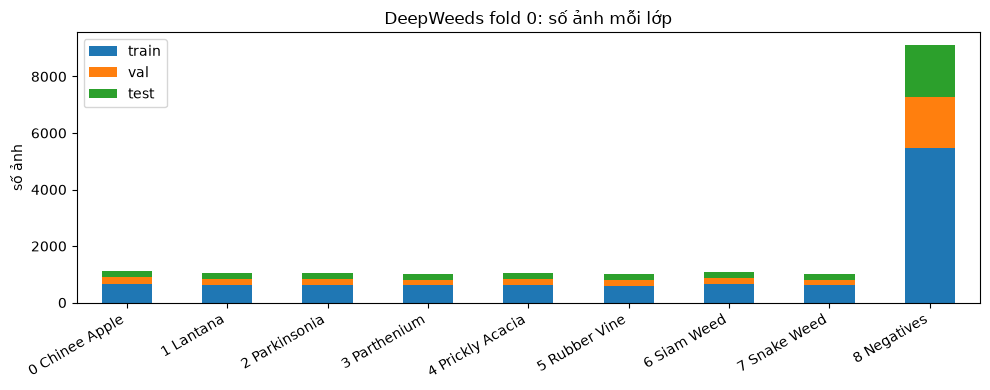

Lớp nhiều nhất / ít nhất = 9106 / 1009 = 9.02 lần; Negatives chiếm 52.0%


,đếm được,bài báo,chênh
0 Chinee Apple,1126,1125,1
1 Lantana,1063,1064,-1
2 Parkinsonia,1031,1031,0
3 Parthenium,1022,1022,0
4 Prickly Acacia,1062,1062,0
5 Rubber Vine,1009,1009,0
6 Siam Weed,1074,1074,0
7 Snake Weed,1016,1016,0
8 Negatives,9106,9106,0


Kích thước, kênh (500 ảnh train ngẫu nhiên): {((256, 256), 'RGB'): 500}


mean RGB [0.379 0.393 0.385] std RGB [0.228 0.228 0.226] | ImageNet mean (0.485, 0.456, 0.406) std (0.229, 0.224, 0.225)


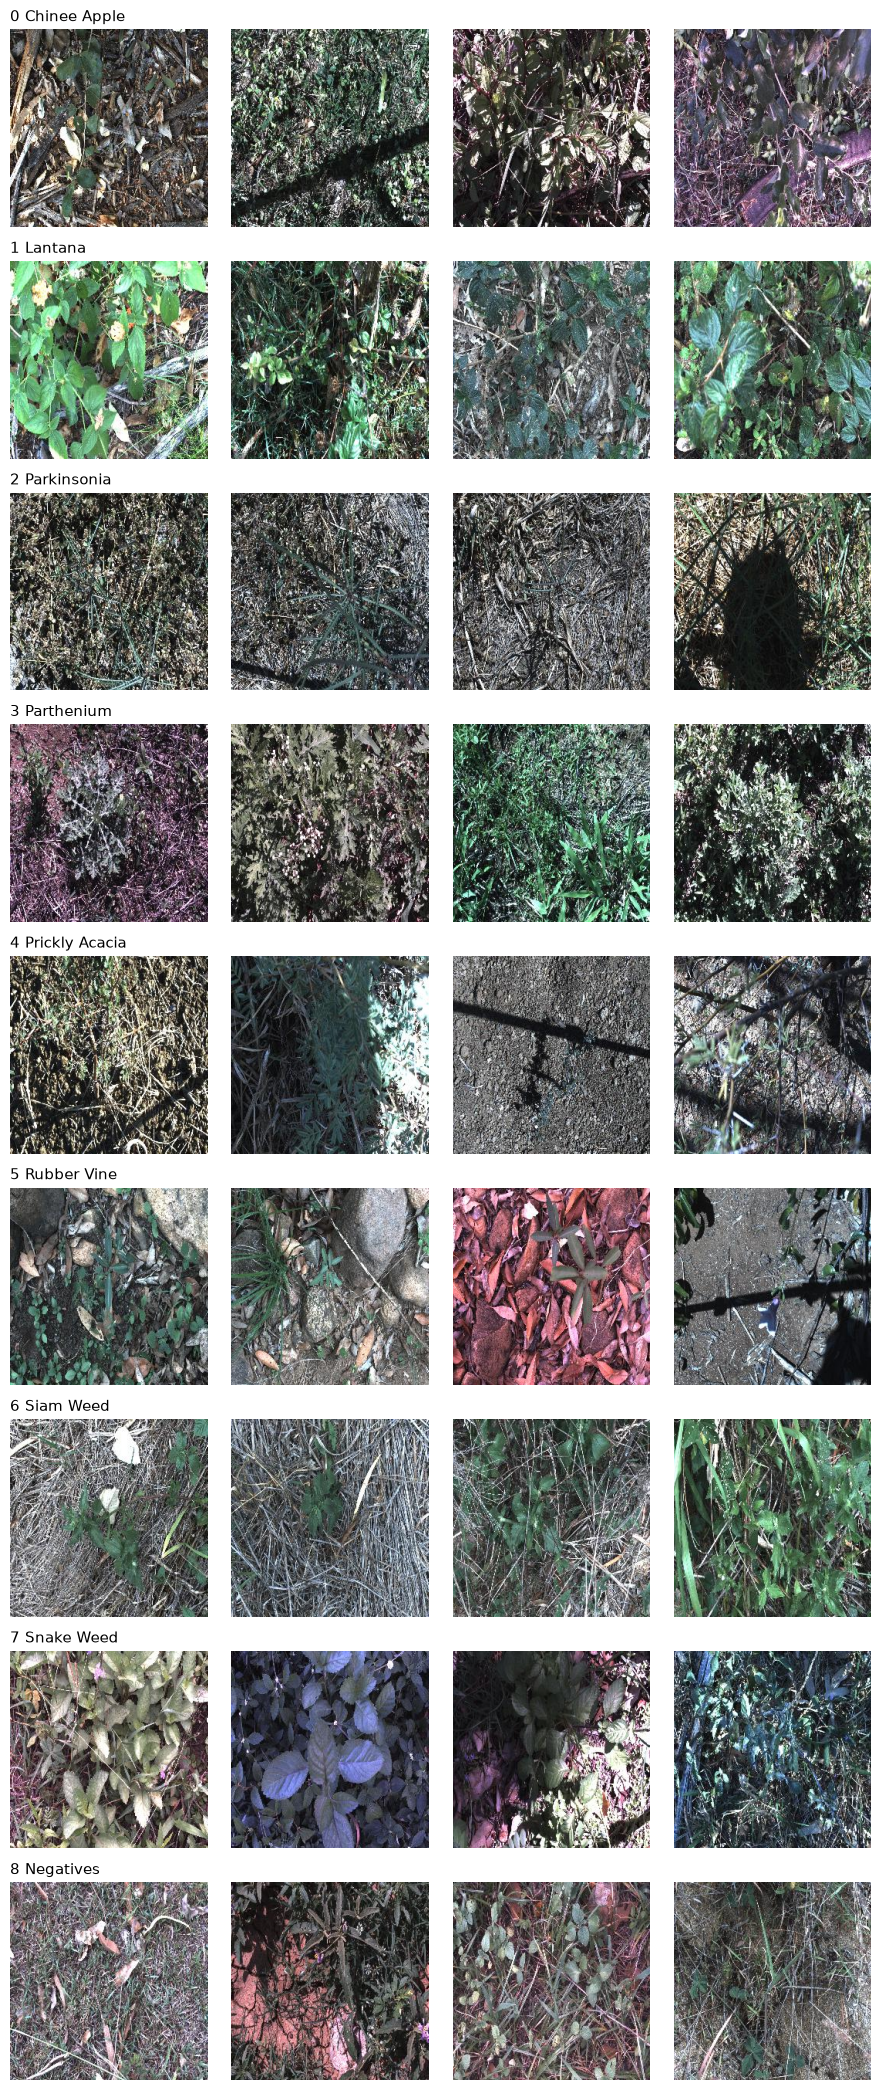

In [6]:
# EDA: phân bố lớp, đối chiếu Table 1 của bài báo, kích thước/kênh ảnh, ảnh mẫu (hình lưu ở eval_out/ trên Drive)
import matplotlib.pyplot as plt
from PIL import Image

pc = split_stats["per_class"]
ax = pc[["train", "val", "test"]].plot.bar(stacked=True, figsize=(10, 4), title="DeepWeeds fold 0: số ảnh mỗi lớp")
ax.set_ylabel("số ảnh"); plt.xticks(rotation=30, ha="right"); plt.tight_layout()
plt.savefig("eval_out/eda_class_distribution.png", dpi=120); plt.show()

tot = pc["total"]
print(f"Lớp nhiều nhất / ít nhất = {tot.max()} / {tot.min()} = {tot.max() / tot.min():.2f} lần;"
      f" Negatives chiếm {tot.iloc[-1] / tot.sum():.1%}")
paper = [1125, 1064, 1031, 1022, 1062, 1009, 1074, 1016, 9106]  # Table 1, Olsen et al. 2019
cmp = pd.DataFrame({"đếm được": tot.values, "bài báo": paper}, index=tot.index)
cmp["chênh"] = cmp["đếm được"] - cmp["bài báo"]
display(cmp)

sample = train_df.sample(500, random_state=0).Filename
info = [(im.size, im.mode) for im in (Image.open(f"{IMAGES_DIR}/{f}") for f in sample)]
print("Kích thước, kênh (500 ảnh train ngẫu nhiên):", pd.Series(info).value_counts().to_dict())
px = np.stack([np.asarray(Image.open(f"{IMAGES_DIR}/{f}").convert("RGB"), dtype=np.float32) / 255 for f in sample[:200]])
print("mean RGB", px.mean((0, 1, 2)).round(3), "std RGB", px.std((0, 1, 2)).round(3),
      "| ImageNet mean", dataset.IMAGENET_MEAN, "std", dataset.IMAGENET_STD)

fig, axes = plt.subplots(9, 4, figsize=(9, 21))
for c in range(9):
    for j, f in enumerate(train_df[train_df.Label == c].sample(4, random_state=0).Filename):
        axes[c, j].imshow(Image.open(f"{IMAGES_DIR}/{f}")); axes[c, j].axis("off")
    axes[c, 0].set_title(f"{c} {dataset.CLASS_NAMES[c]}", loc="left", fontsize=11)
plt.tight_layout(); plt.savefig("eval_out/eda_samples.png", dpi=80); plt.show()


In [7]:
# Kiểm tra model.py: tag trọng số, #params, GMAC, nhóm tham số, đóng băng, loss ban đầu ~ ln 9
import importlib, math, torch, model as M
importlib.reload(M)
rows = []
for key in M.SUGGESTED_BACKBONES:
    m = M.build_model(key, init="finetune")
    groups = {g["name"]: sum(p.numel() for p in g["params"]) for g in M.param_groups(m, 1e-4, 1e-3, 0.05)}
    rows.append({"backbone": key, "tag": M.weight_tag(m), "params_M": round(M.count_params(m), 2),
                 "GMAC": round(M.count_gmacs(m, 224), 2), **{f"n_{k}": v for k, v in groups.items()}})
    del m
display(pd.DataFrame(rows))

# đóng băng: chỉ head còn requires_grad, BN của backbone ở eval sau set_train_mode
m = M.build_model("resnet50", init="frozen")
M.set_train_mode(m)
bn_train = [n for n, x in m.named_modules() if isinstance(x, torch.nn.BatchNorm2d) and x.training]
trainable = [n for n, p in m.named_parameters() if p.requires_grad]
print("frozen: trainable =", trainable, "| BN còn train mode:", len(bn_train))
assert trainable == ["fc.weight", "fc.bias"] and not bn_train

# loss CE ban đầu với head mới phải gần -ln(1/9) = 2.197
m = M.build_model("resnet50").eval()
x = torch.randn(32, 3, 224, 224); y = torch.randint(0, 9, (32,))
with torch.no_grad():
    loss0 = torch.nn.functional.cross_entropy(m(x), y).item()
print(f"loss ban đầu = {loss0:.3f} (kỳ vọng ~ {math.log(9):.3f})")


,backbone,tag,params_M,GMAC,n_backbone,n_backbone_no_decay,n_head
0,resnet50,resnet50.a1_in1k,23.53,4.09,23454912,53120,18441
1,resnext50,resnext50_32x4d.a1h_in1k,23.00,4.23,22911680,68224,18441
2,convnext_tiny,convnext_tiny.in12k_ft_in1k,27.83,4.45,27756000,64128,6921
3,deit_small,deit_small_patch16_224.fb_in1k,21.67,4.60,21528576,137088,3465
4,swin_tiny,swin_tiny_patch4_window7_224.ms_in1k,27.53,4.49,27431424,87930,6921
5,efficientnet_b0,efficientnet_b0.ra_in1k,4.02,0.38,3956192,51356,11529
6,mobilenetv3,mobilenetv3_large_100.ra_in1k,4.21,0.22,4171272,30760,11529


frozen: trainable = ['fc.weight', 'fc.bias'] | BN còn train mode: 0


loss ban đầu = 2.203 (kỳ vọng ~ 2.197)


In [8]:
# Kiểm tra losses.py (GUIDE mục 3.2): focal gamma=0 == CE, label smoothing eps=0 == CE, CutMix lam theo diện tích thật
import losses as L
importlib.reload(L)
torch.manual_seed(0)
logits, y = torch.randn(64, 9), torch.randint(0, 9, (64,))
ce = torch.nn.functional.cross_entropy(logits, y)
assert abs(L.FocalLoss(gamma=0)(logits, y) - ce) < 1e-6, "focal gamma=0 phải bằng CE"
assert abs(L.LabelSmoothingCE(0.0)(logits, y) - ce) < 1e-6, "LS eps=0 phải bằng CE"
assert abs(L.LabelSmoothingCE(0.1)(logits, y) - torch.nn.functional.cross_entropy(logits, y, label_smoothing=0.1)) < 1e-6
print("focal(gamma=2) =", L.FocalLoss(2.0)(logits, y).item(), "< CE =", ce.item())
w = L.class_weights(np.bincount(train_df.Label, minlength=9)); print("class weights (1/n):", w.numpy().round(3))
# Mixup/CutMix: ảnh i có toàn bộ pixel = i, nhãn = i -> đọc được trộn với ảnh nào, bao nhiêu diện tích
x, y = torch.arange(8.).view(8, 1, 1, 1).expand(8, 3, 224, 224).clone(), torch.arange(8)
for trial in range(50):                           # nhiều lần để gặp cả hộp bị cắt ở biên
    np.random.seed(trial); torch.manual_seed(trial)
    xm, (ya, yb, lam) = L.mix_batch(x, y, 1.0, "cutmix")
    assert torch.equal(ya, y) and sorted(yb.tolist()) == list(range(8)), "y_b phải là hoán vị của y"
    for i in range(8):
        kept = (xm[i] == i).float().mean().item()   # phần diện tích còn là ảnh gốc
        if yb[i] != i:
            assert abs(kept - lam) < 1e-5, f"CutMix: lam={lam:.4f} nhưng diện tích giữ lại={kept:.4f}"
            assert torch.all((xm[i] == i) | (xm[i] == yb[i])), "vùng dán phải lấy từ đúng ảnh y_b"
xm, (ya, yb, lam) = L.mix_batch(x, y, 0.4, "mixup")
assert torch.allclose(xm, lam * x + (1 - lam) * x[yb]), "Mixup: x_mix = lam*x + (1-lam)*x[perm]"
mixed = L.mixed_loss(torch.nn.functional.cross_entropy, logits[:8], (ya, yb, lam))
ref = lam * torch.nn.functional.cross_entropy(logits[:8], ya) + (1 - lam) * torch.nn.functional.cross_entropy(logits[:8], yb)
assert abs(mixed - ref) < 1e-6, "mixed_loss = lam*CE(y_a) + (1-lam)*CE(y_b)"
print(f"CutMix: 50 lần, lam luôn = diện tích ảnh gốc còn lại (sau khi hộp bị cắt ở biên); y_b = y[perm]. Mixup và mixed_loss đúng.")
print("OK: các kiểm tra loss đều qua")


focal(gamma=2) = 1.932076096534729 < CE = 2.3471717834472656
class weights (1/n): [1.033 1.095 1.129 1.138 1.095 1.153 1.083 1.145 0.128]


CutMix: 50 lần, lam luôn = diện tích ảnh gốc còn lại (sau khi hộp bị cắt ở biên); y_b = y[perm]. Mixup và mixed_loss đúng.
OK: các kiểm tra loss đều qua


1) seed 0 lặp lại -> cùng file: True | cùng ảnh sau aug: True | cùng head: True
   seed 1          -> cùng file: False | cùng head: False


2) loss ban đầu (batch val thật) = 2.226, kỳ vọng ~ 2.197


3) overfit 18 ảnh: loss 2.179 -> 0.0020 sau 100 bước | acc (eval) 1.00


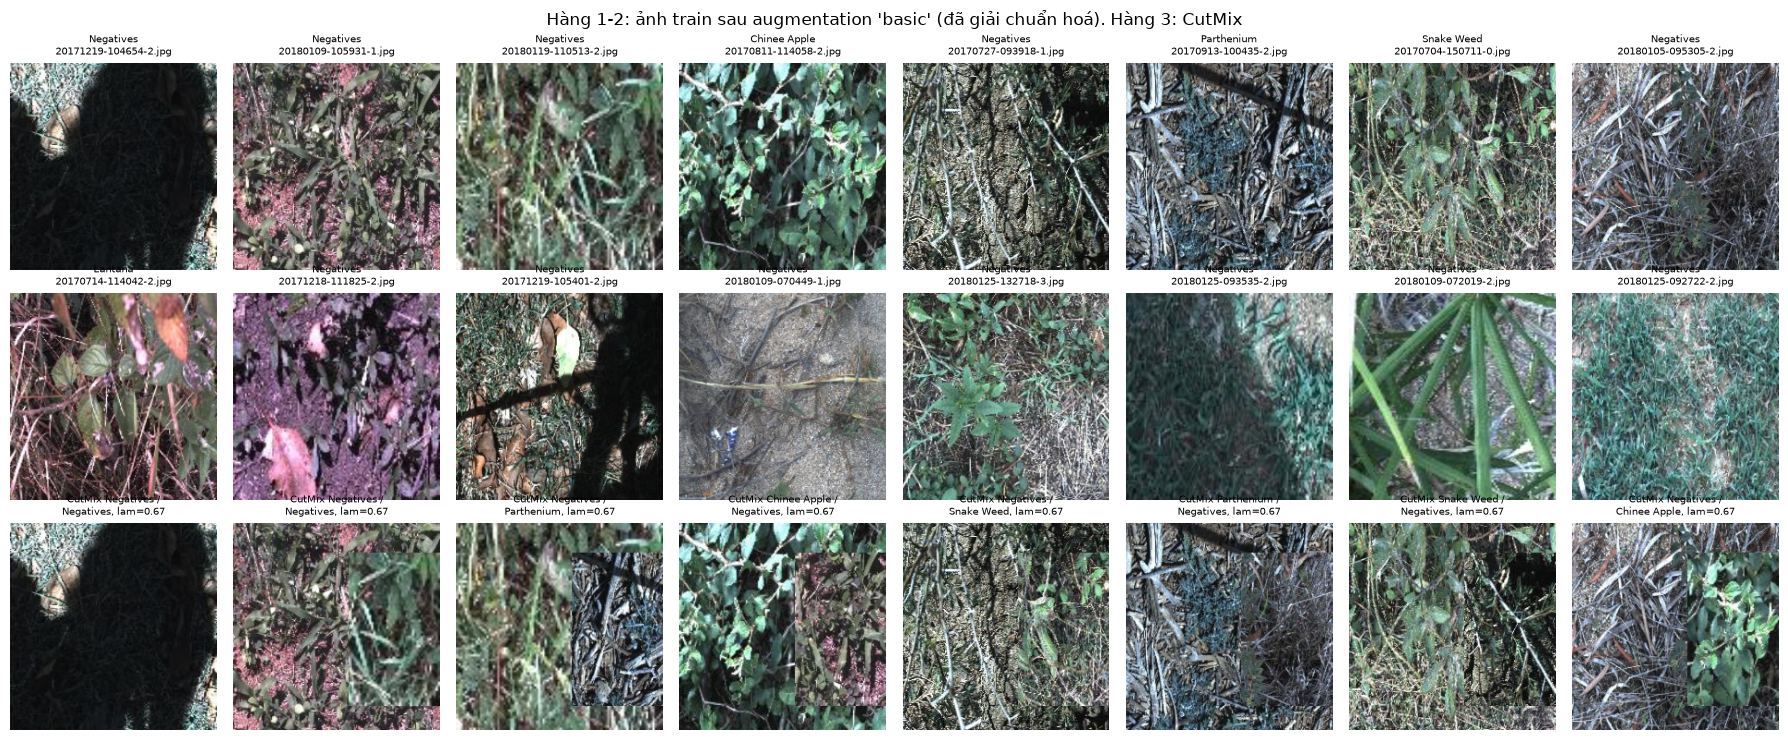

4) nhãn của 16 ảnh khớp CSV: True


5) sau evaluate(): eval mode | eval 2 lần forward giống nhau: True | train mode (dropout) giống nhau: False

OK: qua cả 5 kiểm tra pipeline


In [9]:
# Kiểm tra pipeline (slide trang 59, GUIDE mục 1.3) trước khi chạy thí nghiệm thật
import importlib, math
import dataset as D, model as M, losses as L, train as TR
for mod in (D, M, L, TR):
    importlib.reload(mod)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tf_eval = D.build_transforms(False)

# 1) seed: cùng seed -> cùng thứ tự batch, cùng augmentation, cùng khởi tạo head; seed khác -> khác
def first_batch(seed):
    TR.set_seed(seed)
    head = M.build_model("resnet50").get_classifier().weight.detach().clone()
    dl = D.make_loader(train_df, IMAGES_DIR, D.build_transforms(True), 8, True, num_workers=2, seed=seed)
    x, _, f = next(iter(dl))
    return x, list(f), head
(xa, fa, ha), (xb, fb, hb), (_, fc, hc) = first_batch(0), first_batch(0), first_batch(1)
print("1) seed 0 lặp lại -> cùng file:", fa == fb, "| cùng ảnh sau aug:", torch.equal(xa, xb), "| cùng head:", torch.equal(ha, hb))
print("   seed 1          -> cùng file:", fa == fc, "| cùng head:", torch.equal(ha, hc))
assert fa == fb and torch.equal(xa, xb) and torch.equal(ha, hb) and fa != fc

# 2) loss CE ban đầu trên một batch val THẬT
val_dl = D.make_loader(val_df, IMAGES_DIR, tf_eval, 64, False)
xv, yv, _ = next(iter(val_dl))
m = M.build_model("resnet50").to(device).eval()
with torch.no_grad():
    l0 = torch.nn.functional.cross_entropy(m(xv.to(device)), yv.to(device)).item()
print(f"2) loss ban đầu (batch val thật) = {l0:.3f}, kỳ vọng ~ {math.log(9):.3f}")

# 3) overfit 18 ảnh train (2 ảnh mỗi lớp, không augmentation) tới loss ~ 0
TR.set_seed(0)
small = train_df.groupby("Label").head(2).reset_index(drop=True)
xs = torch.stack([tf_eval(Image.open(f"{IMAGES_DIR}/{f}").convert("RGB")) for f in small.Filename]).to(device)
ys = torch.tensor(small.Label.values, device=device)
m = M.build_model("resnet50").to(device)
opt = torch.optim.AdamW(M.param_groups(m, 1e-4, 1e-3, 0.0))
hist = []
for step in range(100):
    M.set_train_mode(m)
    loss = torch.nn.functional.cross_entropy(m(xs), ys)
    opt.zero_grad(); loss.backward(); opt.step(); hist.append(loss.item())
m.eval()
with torch.no_grad():
    acc = (m(xs).argmax(1) == ys).float().mean().item()
print(f"3) overfit 18 ảnh: loss {hist[0]:.3f} -> {hist[-1]:.4f} sau 100 bước | acc (eval) {acc:.2f}")
assert hist[-1] < 0.1, "không overfit được batch nhỏ: kiểm tra lại code/model trước khi chạy tiếp"

# 4) ảnh sau augmentation (đã giải chuẩn hoá) + nhãn khớp CSV; CutMix trộn cả ảnh lẫn nhãn
dl = D.make_loader(train_df, IMAGES_DIR, D.build_transforms(True, aug="basic"), 16, True, seed=0)
x, y, f = next(iter(dl))
label_of = train_df.set_index("Filename").Label
assert all(label_of[fi] == int(yi) for fi, yi in zip(f, y)), "nhãn trả về không khớp CSV"
mean = torch.tensor(D.IMAGENET_MEAN).view(3, 1, 1); std = torch.tensor(D.IMAGENET_STD).view(3, 1, 1)
show = lambda t: (t.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0)
xm, (ya, yb, lam) = L.mix_batch(x[:8], y[:8], 1.0, "cutmix")
fig, axes = plt.subplots(3, 8, figsize=(18, 7.5))
for k in range(16):
    a = axes.flat[k]; a.imshow(show(x[k])); a.axis("off")
    a.set_title(f"{D.CLASS_NAMES[int(y[k])]}\n{f[k]}", fontsize=7)
for k in range(8):
    a = axes[2, k]; a.imshow(show(xm[k])); a.axis("off")
    a.set_title(f"CutMix {D.CLASS_NAMES[int(ya[k])]} /\n{D.CLASS_NAMES[int(yb[k])]}, lam={lam:.2f}", fontsize=7)
plt.suptitle("Hàng 1-2: ảnh train sau augmentation 'basic' (đã giải chuẩn hoá). Hàng 3: CutMix")
plt.tight_layout(); plt.savefig("eval_out/check_augmentation.png", dpi=90); plt.show()
print("4) nhãn của 16 ảnh khớp CSV: True")

# 5) train/eval mode: evaluate() đưa model về eval; eval cho kết quả cố định, train (dropout) thì không
m = M.build_model("resnet50", drop_rate=0.5).to(device)
M.set_train_mode(m)
TR.evaluate(m, D.make_loader(val_df.head(16), IMAGES_DIR, tf_eval, 8, False, num_workers=0),
            torch.nn.CrossEntropyLoss(), device)
assert not any(mm.training for mm in m.modules()), "evaluate() phải đặt model.eval()"
x4 = xv[:4].to(device)
with torch.no_grad():
    same_eval = torch.allclose(m(x4), m(x4))
    M.set_train_mode(m)
    same_train = torch.allclose(m(x4), m(x4))
print("5) sau evaluate(): eval mode | eval 2 lần forward giống nhau:", same_eval, "| train mode (dropout) giống nhau:", same_train)
assert same_eval and not same_train
print("\nOK: qua cả 5 kiểm tra pipeline")


[B00 seed0] đã xong trước đó, bỏ qua (xoá eval_out/debug/runs/B00/seed0 để chạy lại)
['best.pt', 'config.json', 'history.csv', 'steps.csv', 'summary.json', 'val_logits.npy']


,epoch,train_loss,train_acc,val_loss,val_macro_f1,val_top1,val_balanced_acc,val_ece,train_time_s,epoch_time_s
0,1,1.649125,0.481231,1.256519,0.210133,0.561839,0.193599,0.068793,22.57198,41.446394


,Filename,y_true,y_pred,p0,p1,p2,p3,p4,p5,p6,p7,p8
0,20171219-113902-3.jpg,8,8,0.047488,0.045225,0.129814,0.125039,0.150987,0.040698,0.041339,0.042402,0.377007
1,20180112-101728-2.jpg,8,8,0.029826,0.023733,0.011841,0.014895,0.008834,0.021005,0.014536,0.018884,0.856446
2,20171205-144809-2.jpg,8,8,0.035631,0.075985,0.023436,0.023436,0.015176,0.102976,0.079515,0.041779,0.602065


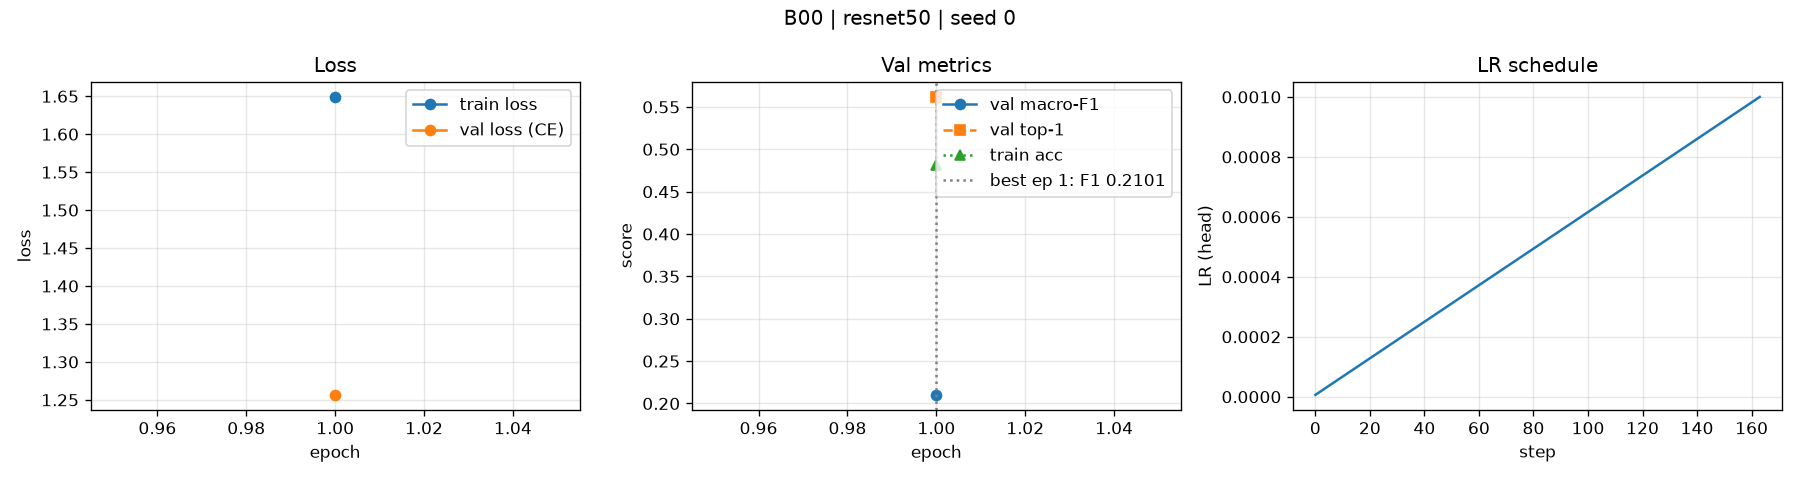

parse_overrides: {'exp_id': 'B01', 'seed': 1, 'loss': 'focal', 'ema_decay': None, 'amp': False, 'lr_head': 0.003}


In [10]:
# Chạy thử run(Config(...)) từ đầu đến cuối: 1 epoch, ghi vào thư mục debug (KHÔNG phải kết quả thí nghiệm)
from IPython.display import Image as IPImage
importlib.reload(TR)
dbg = TR.Config(exp_id="B00", desc="smoke", epochs=1, out_dir="eval_out/debug/runs",
                pred_dir="eval_out/debug/predictions", curves_dir="eval_out/debug/curves")
summary = TR.run(dbg)
rd = TR.run_dir(dbg)
print(sorted(p.name for p in rd.iterdir()))
display(pd.read_csv(rd / "history.csv"))
display(pd.read_csv(TR.pred_path(dbg, "val")).head(3))
display(IPImage(filename=str(TR.curve_path(dbg))))
print("parse_overrides:", TR.parse_overrides(["exp_id=B01", "seed=1", "loss=focal", "ema_decay=none", "amp=false", "lr_head=3e-3"]))


In [11]:
# Bộ test của repo (eval.py + khung code), không cần GPU
!{sys.executable} -m unittest discover -s tests 2>&1 | tail -5


..............................
----------------------------------------------------------------------
Ran 38 tests in 2.444s

OK


## Ngân sách GPU: đo 1 epoch mỗi backbone
Mỗi backbone chạy **1 epoch train + 1 lượt val** với công thức nền (batch 64, AMP, 224). Không ghi gì ra `runs/`.
Từ đó ước lượng tổng thời gian cho kế hoạch ~20-25 lần huấn luyện và quyết định ablation trên 1 hay 2 backbone (GUIDE mục 7).
Ghi bảng này vào báo cáo; mọi cắt giảm (epoch, số backbone ablation...) cũng phải ghi lại.

In [12]:
import importlib, train as TR
importlib.reload(TR)
from train import Config, measure_epoch_time

BUDGET_BACKBONES = ["resnet50", "resnext50", "convnext_tiny", "deit_small", "swin_tiny", "efficientnet_b0", "mobilenetv3"]
timing = []
for bb in BUDGET_BACKBONES:
    r = measure_epoch_time(Config(backbone=bb))          # đủ 1 epoch; max_batches=40 để đo nhanh (ngoại suy)
    timing.append(r)
    print(f"{bb:16s} train {r['train_epoch_s']:6.0f}s | val {r['val_s']:5.0f}s | mem {r['peak_mem_GB']:.1f} GB")
timing = pd.DataFrame(timing).set_index("backbone")
timing.to_csv("eval_out/epoch_timing.csv")             # lưu ra Drive
display(timing.round(1))


Số ảnh: {'train': '10501 (60.0%)', 'val': '3501 (20.0%)', 'test': '3507 (20.0%)'} | tổng 17509
Giao từng cặp: {'train&val': 0, 'train&test': 0, 'val&test': 0} | hợp: 17509 | thiếu file: 0
                  train   val  test  total
0 Chinee Apple      675   225   226   1126
1 Lantana           637   213   213   1063
2 Parkinsonia       618   206   207   1031
3 Parthenium        613   204   205   1022
4 Prickly Acacia    637   212   213   1062
5 Rubber Vine       605   202   202   1009
6 Siam Weed         644   215   215   1074
7 Snake Weed        609   203   204   1016
8 Negatives        5463  1821  1822   9106


resnet50         train     22s | val    19s | mem 4.1 GB
Số ảnh: {'train': '10501 (60.0%)', 'val': '3501 (20.0%)', 'test': '3507 (20.0%)'} | tổng 17509
Giao từng cặp: {'train&val': 0, 'train&test': 0, 'val&test': 0} | hợp: 17509 | thiếu file: 0
                  train   val  test  total
0 Chinee Apple      675   225   226   1126
1 Lantana           637   213   213   1063
2 Parkinsonia       618   206   207   1031
3 Parthenium        613   204   205   1022
4 Prickly Acacia    637   212   213   1062
5 Rubber Vine       605   202   202   1009
6 Siam Weed         644   215   215   1074
7 Snake Weed        609   203   204   1016
8 Negatives        5463  1821  1822   9106


/workspace/K4-Track4-Day2-DangHuuTam-2A202602940-Deeplearning-Advance/submissions/2A202602940_dang_huu_tam/code/train.py:228: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


resnext50        train     23s | val    14s | mem 4.6 GB
Số ảnh: {'train': '10501 (60.0%)', 'val': '3501 (20.0%)', 'test': '3507 (20.0%)'} | tổng 17509
Giao từng cặp: {'train&val': 0, 'train&test': 0, 'val&test': 0} | hợp: 17509 | thiếu file: 0
                  train   val  test  total
0 Chinee Apple      675   225   226   1126
1 Lantana           637   213   213   1063
2 Parkinsonia       618   206   207   1031
3 Parthenium        613   204   205   1022
4 Prickly Acacia    637   212   213   1062
5 Rubber Vine       605   202   202   1009
6 Siam Weed         644   215   215   1074
7 Snake Weed        609   203   204   1016
8 Negatives        5463  1821  1822   9106


/workspace/K4-Track4-Day2-DangHuuTam-2A202602940-Deeplearning-Advance/submissions/2A202602940_dang_huu_tam/code/train.py:228: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


...

deit_small       train      7s | val     2s | mem 3.1 GB
Số ảnh: {'train': '10501 (60.0%)', 'val': '3501 (20.0%)', 'test': '3507 (20.0%)'} | tổng 17509
Giao từng cặp: {'train&val': 0, 'train&test': 0, 'val&test': 0} | hợp: 17509 | thiếu file: 0
                  train   val  test  total
0 Chinee Apple      675   225   226   1126
1 Lantana           637   213   213   1063
2 Parkinsonia       618   206   207   1031
3 Parthenium        613   204   205   1022
4 Prickly Acacia    637   212   213   1062
5 Rubber Vine       605   202   202   1009
6 Siam Weed         644   215   215   1074
7 Snake Weed        609   203   204   1016
8 Negatives        5463  1821  1822   9106


swin_tiny        train     12s | val     2s | mem 5.6 GB
Số ảnh: {'train': '10501 (60.0%)', 'val': '3501 (20.0%)', 'test': '3507 (20.0%)'} | tổng 17509
Giao từng cặp: {'train&val': 0, 'train&test': 0, 'val&test': 0} | hợp: 17509 | thiếu file: 0
                  train   val  test  total
0 Chinee Apple      675   225   226   1126
1 Lantana           637   213   213   1063
2 Parkinsonia       618   206   207   1031
3 Parthenium        613   204   205   1022
4 Prickly Acacia    637   212   213   1062
5 Rubber Vine       605   202   202   1009
6 Siam Weed         644   215   215   1074
7 Snake Weed        609   203   204   1016
8 Negatives        5463  1821  1822   9106


efficientnet_b0  train     54s | val    36s | mem 3.5 GB
Số ảnh: {'train': '10501 (60.0%)', 'val': '3501 (20.0%)', 'test': '3507 (20.0%)'} | tổng 17509
Giao từng cặp: {'train&val': 0, 'train&test': 0, 'val&test': 0} | hợp: 17509 | thiếu file: 0
                  train   val  test  total
0 Chinee Apple      675   225   226   1126
1 Lantana           637   213   213   1063
2 Parkinsonia       618   206   207   1031
3 Parthenium        613   204   205   1022
4 Prickly Acacia    637   212   213   1062
5 Rubber Vine       605   202   202   1009
6 Siam Weed         644   215   215   1074
7 Snake Weed        609   203   204   1016
8 Negatives        5463  1821  1822   9106


mobilenetv3      train     42s | val    26s | mem 2.3 GB


,batch_size,img_size,train_epoch_s,val_s,epoch_s,extrapolated,peak_mem_GB
backbone,,,,,,,
resnet50,64,224,22.2,19.2,41.4,False,4.1
resnext50,64,224,22.8,14.1,36.8,False,4.6
convnext_tiny,64,224,29.3,13.0,42.4,False,5.1
deit_small,64,224,7.0,1.7,8.7,False,3.1
swin_tiny,64,224,11.8,2.4,14.2,False,5.6
efficientnet_b0,64,224,54.2,36.0,90.2,False,3.5
mobilenetv3,64,224,41.9,26.4,68.3,False,2.3


In [13]:
# Kế hoạch: sửa số lần chạy cho đúng ý bạn, rồi so với hạn mức GPU (Colab free: không cố định, thường vài giờ/phiên).
EPOCHS = 12
ABLATION_BACKBONES = ["resnet50"]          # 1 backbone; thêm cái thứ 2 nếu tổng giờ còn dư
N_ABLATION_RUNS = 12                       # trục A-G, mỗi lần khác T00 một yếu tố
FINAL_SEEDS = 3                            # F01 x 3 seed + mốc T00 thêm 2 seed (seed0 dùng lại từ Bước 2)

ep = timing["epoch_s"] / 3600              # giờ / epoch
hours = {
    "B: backbones x 1 seed": ep[BUDGET_BACKBONES].sum() * EPOCHS,
    "T: ablation": sum(ep[b] for b in ABLATION_BACKBONES) * EPOCHS * N_ABLATION_RUNS,
    "F: chung kết + mốc": ep[ABLATION_BACKBONES[0]] * EPOCHS * (FINAL_SEEDS + FINAL_SEEDS - 1),
}
plan = pd.Series(hours).round(2); plan["TỔNG (giờ GPU)"] = plan.sum(); plan["+20% chạy hỏng"] = plan.iloc[-1] * 1.2
display(plan.to_frame("giờ"))


,giờ
B: backbones x 1 seed,1.010
T: ablation,1.660
F: chung kết + mốc,0.690
TỔNG (giờ GPU),3.360
+20% chạy hỏng,4.032


## Bước 1 — So sánh backbone (≥ 5)
Cùng công thức nền `T00` (GUIDE.md mục 1.4), cùng seed, mỗi backbone một lần chạy. Mã thí nghiệm `B01`, `B02`, ...

In [14]:
# Bước 1a: huấn luyện 7 backbone với công thức nền T00, cùng seed 0 (~1,5 giờ trên T4)
# Bị ngắt giữa chừng: chạy lại ô này -> backbone đã xong được bỏ qua, backbone dở dang chạy tiếp từ epoch đã lưu.
!git pull -q
import importlib, dataset as D, model as M, losses as L, train as TR, benchmark as BM
for mod in (D, M, L, TR, BM):
    importlib.reload(mod)

BACKBONE_RUNS = [            # (exp_id, backbone): đủ ResNet, ResNeXt/ConvNeXt, transformer, mạng nhẹ
    ("B01", "resnet50"),
    ("B02", "resnext50"),
    ("B03", "convnext_tiny"),
    ("B04", "deit_small"),
    ("B05", "swin_tiny"),
    ("B06", "efficientnet_b0"),
    ("B07", "mobilenetv3"),
]
for exp_id, bb in BACKBONE_RUNS:
    TR.run(TR.Config(exp_id=exp_id, backbone=bb, desc=bb, seed=0))


[B01 seed0] đã xong trước đó, bỏ qua (xoá runs/B01/seed0 để chạy lại)
[B02 seed0] đã xong trước đó, bỏ qua (xoá runs/B02/seed0 để chạy lại)
[B03 seed0] đã xong trước đó, bỏ qua (xoá runs/B03/seed0 để chạy lại)
[B04 seed0] đã xong trước đó, bỏ qua (xoá runs/B04/seed0 để chạy lại)
[B05 seed0] đã xong trước đó, bỏ qua (xoá runs/B05/seed0 để chạy lại)
[B06 seed0] đã xong trước đó, bỏ qua (xoá runs/B06/seed0 để chạy lại)
[B07 seed0] đã xong trước đó, bỏ qua (xoá runs/B07/seed0 để chạy lại)


,exp_id,backbone,tag trọng số,#tham số (M),GMAC,độ phân giải,epoch,seed,macro-F1 val,top-1 val,...,F1 val epoch 1,epoch đầu đạt 98% F1 tốt nhất,best epoch,val loss min @epoch,train loss cuối,val loss cuối,thời gian train/epoch (s),độ trễ batch-1 p50 (ms),độ trễ batch-1 p95 (ms),ghi chú
2,B03,convnext_tiny,convnext_tiny.in12k_ft_in1k,27.83,4.45,224,12,0,0.9699,0.9763,...,0.8441,6,10,12,0.0357,0.0985,8.6,4.00,4.09,"1 seed; FP32, NVIDIA GeForce RTX 4090, không t..."
3,B04,deit_small,deit_small_patch16_224.fb_in1k,21.67,4.60,224,12,0,0.9546,0.9663,...,0.8383,8,11,12,0.0468,0.1117,6.6,3.43,3.46,"1 seed; FP32, NVIDIA GeForce RTX 4090, không t..."
4,B05,swin_tiny,swin_tiny_patch4_window7_224.ms_in1k,27.53,4.49,224,12,0,0.9541,0.9669,...,0.7842,7,12,12,0.0589,0.1304,11.2,6.92,7.12,"1 seed; FP32, NVIDIA GeForce RTX 4090, không t..."
0,B01,resnet50,resnet50.a1_in1k,23.53,4.09,224,12,0,0.7933,0.8509,...,0.2101,7,11,11,0.3815,0.4403,7.2,4.51,4.56,"1 seed; FP32, NVIDIA GeForce RTX 4090, không t..."
5,B06,efficientnet_b0,efficientnet_b0.ra_in1k,4.02,0.38,224,12,0,0.7720,0.8323,...,0.3860,11,12,12,0.2269,0.5282,8.3,5.87,6.19,"1 seed; FP32, NVIDIA GeForce RTX 4090, không t..."
1,B02,resnext50,resnext50_32x4d.a1h_in1k,23.00,4.23,224,12,0,0.7635,0.8163,...,0.1886,9,11,11,0.2168,0.5285,8.3,4.44,4.50,"1 seed; FP32, NVIDIA GeForce RTX 4090, không t..."
6,B07,mobilenetv3,mobilenetv3_large_100.ra_in1k,4.21,0.22,224,12,0,0.6887,0.7644,...,0.3653,6,6,6,0.2218,0.6940,6.6,4.61,4.71,"1 seed; FP32, NVIDIA GeForce RTX 4090, không t..."


curves: ['B01_resnet50.png', 'B02_resnext50.png', 'B03_convnext_tiny.png', 'B04_deit_small.png', 'B05_swin_tiny.png', 'B06_efficientnet_b0.png', 'B07_mobilenetv3.png', 'T00_base.png', 'T00_base_seed1.png', 'T00_base_seed2.png'] | thiếu: []
B01 resnet50         val loss min ep 11, cuối cao hơn min +0.9% | train loss 1.649 -> 0.381
B02 resnext50        val loss min ep 11, cuối cao hơn min +4.2% | train loss 1.622 -> 0.217
B03 convnext_tiny    val loss min ep 12, cuối cao hơn min +0.0% | train loss 0.755 -> 0.036
B04 deit_small       val loss min ep 12, cuối cao hơn min +0.0% | train loss 0.928 -> 0.047
B05 swin_tiny        val loss min ep 12, cuối cao hơn min +0.0% | train loss 0.992 -> 0.059
B06 efficientnet_b0  val loss min ep 12, cuối cao hơn min +0.0% | train loss 2.138 -> 0.227
B07 mobilenetv3      val loss min ep  6, cuối cao hơn min +2.2% | train loss 1.863 -> 0.222


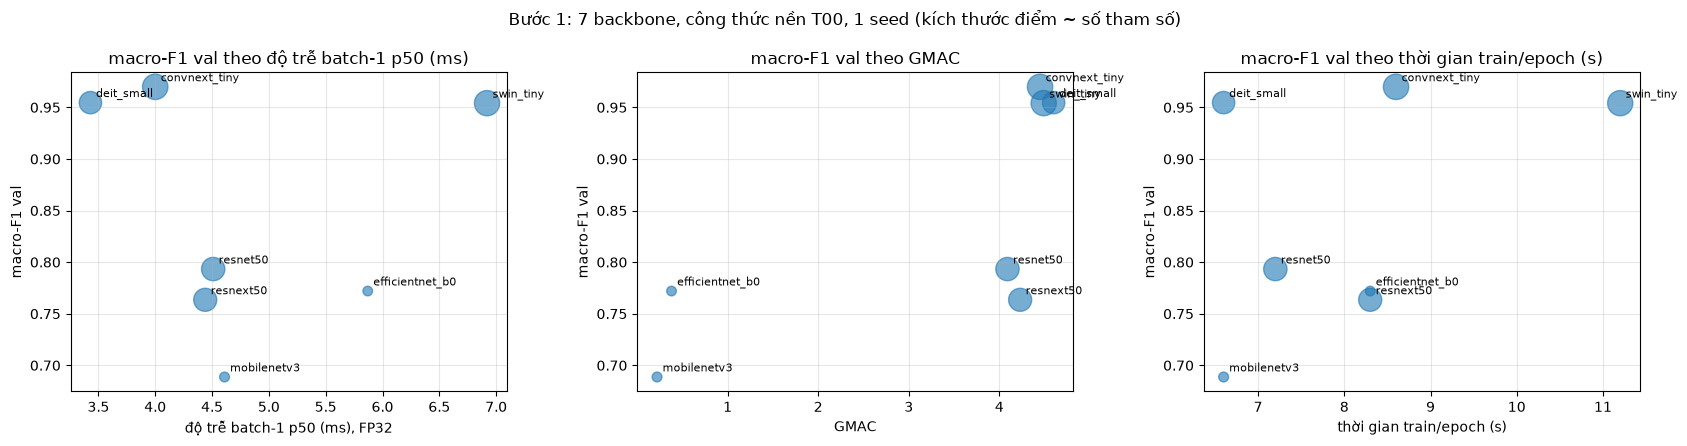

In [15]:
# Bước 1b: bảng Backbones (+ độ trễ sơ bộ batch 1) và biểu đồ đánh đổi. KHÔNG train: chỉ đọc kết quả B01-B07.
import json, importlib, torch
import matplotlib.pyplot as plt
import dataset as D, model as M, train as TR, benchmark as BM
for mod in (D, M, TR, BM):
    importlib.reload(mod)
BACKBONE_RUNS = [("B01", "resnet50"), ("B02", "resnext50"), ("B03", "convnext_tiny"), ("B04", "deit_small"),
                 ("B05", "swin_tiny"), ("B06", "efficientnet_b0"), ("B07", "mobilenetv3")]
device = torch.device("cuda")
rows = []
for exp_id, bb in BACKBONE_RUNS:
    cfg = TR.Config(exp_id=exp_id, backbone=bb, desc=bb, seed=0)
    rd = TR.run_dir(cfg)
    s = json.loads((rd / "summary.json").read_text(encoding="utf-8"))
    h = pd.read_csv(rd / "history.csv")
    m = M.build_model(bb, pretrained=False).to(device)
    m.load_state_dict(torch.load(rd / "best.pt", map_location=device, weights_only=True))
    lat = BM.latency_report(m, batch_size=1, img_size=cfg.img_size, dtype="fp32", iters=50)
    rows.append({
        "exp_id": exp_id, "backbone": bb, "tag trọng số": s["weight_tag"],
        "#tham số (M)": round(s["params_M"], 2), "GMAC": round(s["gmacs"], 2),
        "độ phân giải": cfg.img_size, "epoch": cfg.epochs, "seed": cfg.seed,
        "macro-F1 val": round(s["val_macro_f1"], 4), "top-1 val": round(s["val_top1"], 4),
        "F1 Chinee apple val": round(s["val_f1_per_class"][0], 4), "F1 Snake weed val": round(s["val_f1_per_class"][7], 4),
        "F1 val epoch 1": round(h.val_macro_f1.iloc[0], 4),
        "epoch đầu đạt 98% F1 tốt nhất": int(h.loc[h.val_macro_f1 >= 0.98 * h.val_macro_f1.max(), "epoch"].iloc[0]),
        "best epoch": s["best_epoch"], "val loss min @epoch": int(h.loc[h.val_loss.idxmin(), "epoch"]),
        "train loss cuối": round(h.train_loss.iloc[-1], 4), "val loss cuối": round(h.val_loss.iloc[-1], 4),
        "thời gian train/epoch (s)": round(s["train_time_per_epoch_s"], 1),
        "độ trễ batch-1 p50 (ms)": round(lat["p50"], 2), "độ trễ batch-1 p95 (ms)": round(lat["p95"], 2),
        "ghi chú": f"1 seed; FP32, {lat['gpu']}, không tính tiền xử lý",
    })
    del m; torch.cuda.empty_cache()
backbones = pd.DataFrame(rows)
backbones.to_csv("eval_out/backbones.csv", index=False)
# results.xlsx nằm ở thư mục lưu bền (eval_out/), mỗi bước ghi đè đúng sheet của mình, giữ các sheet khác
XLSX = "eval_out/results.xlsx"
with pd.ExcelWriter(XLSX, engine="openpyxl", **({"mode": "a", "if_sheet_exists": "replace"} if os.path.exists(XLSX) else {})) as w:
    backbones.to_excel(w, sheet_name="Backbones", index=False)
display(backbones.sort_values("macro-F1 val", ascending=False))

# Ảnh đường cong của từng B0x phải có trong curves/
missing = [e for e, b in BACKBONE_RUNS if not TR.curve_path(TR.Config(exp_id=e, backbone=b, desc=b)).exists()]
print("curves:", sorted(os.listdir("curves")), "| thiếu:", missing)
# Overfit rõ: val loss cuối cao hơn val loss nhỏ nhất > 10% trong khi train loss vẫn giảm
for _, r in backbones.iterrows():
    h = pd.read_csv(TR.run_dir(TR.Config(exp_id=r.exp_id, backbone=r.backbone)) / "history.csv")
    rise = h.val_loss.iloc[-1] / h.val_loss.min() - 1
    print(f"{r.exp_id} {r.backbone:16s} val loss min ep {h.val_loss.idxmin() + 1:2d}, cuối cao hơn min {rise:+.1%}"
          f" | train loss {h.train_loss.iloc[0]:.3f} -> {h.train_loss.iloc[-1]:.3f}")

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
for a, x, xl in [(ax[0], "độ trễ batch-1 p50 (ms)", "độ trễ batch-1 p50 (ms), FP32"),
                 (ax[1], "GMAC", "GMAC"), (ax[2], "thời gian train/epoch (s)", "thời gian train/epoch (s)")]:
    a.scatter(backbones[x], backbones["macro-F1 val"], s=backbones["#tham số (M)"] * 12, alpha=0.6)
    for _, r in backbones.iterrows():
        a.annotate(r.backbone, (r[x], r["macro-F1 val"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
    a.set(xlabel=xl, ylabel="macro-F1 val", title=f"macro-F1 val theo {xl.split(',')[0]}"); a.grid(alpha=0.3)
fig.suptitle("Bước 1: 7 backbone, công thức nền T00, 1 seed (kích thước điểm ~ số tham số)")
plt.tight_layout(); plt.savefig("eval_out/backbones_tradeoff.png", dpi=120); plt.show()


## Bước 2 — Công thức huấn luyện (≥ 3 trục)
Trên **1 backbone** chọn ở Bước 1 (ngân sách GPU, xem báo cáo mục 2.5). Mỗi `T0x` khác `T00` **đúng một yếu tố**, cùng seed 0, cùng 12 epoch.
- Trục A khởi tạo (`T01` từ đầu, `T02` đóng băng) · B augmentation (`T03` lật dọc, `T04` màu, `T05` TrivialAugment, `T06` CutMix) · C loss (`T07` label smoothing, `T08` focal, `T09` CE trọng số) · D sampler cân bằng (`T10`) · E LR head = LR backbone (`T11`) · F EMA (`T12`).
- **Nhiễu:** `T00` chạy 3 seed (seed 0 dùng lại `B0x` vì cùng cấu hình); std macro-F1 qua 3 seed là ngưỡng: |Δ| ≤ std thì "không phân biệt được". Ba lần chạy này cũng là mốc `T00` của Bước 4.
- **Không tham lam theo trục:** mọi `T0x` so với cùng nền `T00`; sau đó `T13` kết hợp giá trị tốt nhất của mỗi trục B–F (chọn trên val) để xem cộng dồn hay triệt tiêu.
- Ước tính ~15 lần chạy × ~10 phút (resnet50 trên T4); bị ngắt thì chạy lại ô 2a, lần đã xong được bỏ qua.


In [16]:
# Bước 2a: ablation công thức huấn luyện trên 1 backbone (chọn ở Bước 1). Mỗi T0x khác T00 đúng MỘT yếu tố.
# Không dùng cách tham lam: mọi T0x so với cùng một nền T00 (seed 0), rồi thử một kết hợp ở Bước 2b.
# Bị ngắt giữa chừng: chạy lại ô này -> lần chạy đã xong được bỏ qua, lần dở dang chạy tiếp từ epoch đã lưu.
!git pull -q
import json, shutil, importlib
import dataset as D, model as M, losses as L, train as TR
for mod in (D, M, L, TR):
    importlib.reload(mod)

ABL_BB = "convnext_tiny"   # chọn ở Bước 1: macro-F1 val cao nhất (B03 0,9702 > swin 0,9612 > deit 0,9452), train nhanh hơn swin
BACKBONE_RUNS = [("B01", "resnet50"), ("B02", "resnext50"), ("B03", "convnext_tiny"), ("B04", "deit_small"),
                 ("B05", "swin_tiny"), ("B06", "efficientnet_b0"), ("B07", "mobilenetv3")]
assert ABL_BB in dict((b, e) for e, b in BACKBONE_RUNS), "Điền ABL_BB = backbone đã chọn ở Bước 1"
B_EXP = dict((b, e) for e, b in BACKBONE_RUNS)[ABL_BB]

def T(exp_id, desc, seed=0, **kw):
    """Config của Bước 2: công thức nền T00 trên ABL_BB, chỉ đổi các trường trong kw."""
    return TR.Config(exp_id=exp_id, backbone=ABL_BB, desc=desc, seed=seed, **kw)

def reuse_run(src_cfg, dst_cfg):
    """T00 seed 0 có cấu hình GIỐNG HỆT B0x của Bước 1 (cùng backbone, công thức nền, seed 0):
    chép kết quả sang T00 thay vì train lại (tiết kiệm 1 lần chạy), ghi rõ nguồn trong summary.json."""
    src, dst = TR.run_dir(src_cfg), TR.run_dir(dst_cfg)
    if (dst / "summary.json").exists():
        return
    assert (src / "summary.json").exists(), f"chưa có {src}: chạy Bước 1 trước"
    shutil.copytree(src, dst, dirs_exist_ok=True)
    for name in ("summary.json", "config.json"):
        j = json.loads((dst / name).read_text(encoding="utf-8"))
        if "exp_id" in j:
            j["exp_id"] = dst_cfg.exp_id
        if "config" in j:
            j["config"].update(exp_id=dst_cfg.exp_id, desc=dst_cfg.desc)
        j["reused_from"] = src_cfg.exp_id
        (dst / name).write_text(json.dumps(j, indent=2, ensure_ascii=False), encoding="utf-8")
    shutil.copy(TR.pred_path(src_cfg, "val"), TR.pred_path(dst_cfg, "val"))
    shutil.copy(TR.curve_path(src_cfg), TR.curve_path(dst_cfg))
    print(f"T00 seed0 = {src_cfg.exp_id} (cùng cấu hình), đã chép sang {dst}")

reuse_run(TR.Config(exp_id=B_EXP, backbone=ABL_BB, desc=ABL_BB, seed=0), T("T00", "base"))

# Đo nhiễu: T00 thêm seed 1, 2 -> std macro-F1 qua 3 seed dùng để so mọi Δ của bước này.
# Ba lần chạy này cũng chính là mốc T00 của Bước 4 (chỉ cần chạy test sau), nên không tốn thêm.
for seed in (1, 2):
    TR.run(T("T00", "base", seed=seed))

ABLATIONS = [  # (exp_id, trục, khác T00 ở điểm nào, tên ngắn cho curves/, thay đổi Config) - rút gọn do ngân sách GPU
    ("T02", "A", "khởi tạo: đóng băng backbone, chỉ train head",      "frozen",   dict(init="frozen")),
    ("T07", "C", "loss: CE + label smoothing eps = 0,1",              "ls",       dict(loss="ls")),
    ("T06", "B", "augmentation: + CutMix (alpha = 1)",                "cutmix",   dict(mix="cutmix")),
    ("T08", "C", "loss: focal gamma = 2",                             "focal",    dict(loss="focal")),
    ("T05", "B", "augmentation: + TrivialAugmentWide",                "trivial",  dict(aug="trivial")),
    ("T12", "F", "EMA trọng số, decay = 0,998 (đánh giá bằng EMA)",   "ema",      dict(ema_decay=0.998)),
]

for exp_id, axis, what, slug, kw in ABLATIONS:
    print(f"\n=== {exp_id} [{axis}] {what}")
    TR.run(T(exp_id, slug, **kw))


[T00 seed1] đã xong trước đó, bỏ qua (xoá runs/T00/seed1 để chạy lại)
[T00 seed2] đã xong trước đó, bỏ qua (xoá runs/T00/seed2 để chạy lại)

=== T02 [A] khởi tạo: đóng băng backbone, chỉ train head


Số ảnh: {'train': '10501 (60.0%)', 'val': '3501 (20.0%)', 'test': '3507 (20.0%)'} | tổng 17509
Giao từng cặp: {'train&val': 0, 'train&test': 0, 'val&test': 0} | hợp: 17509 | thiếu file: 0
                  train   val  test  total
0 Chinee Apple      675   225   226   1126
1 Lantana           637   213   213   1063
2 Parkinsonia       618   206   207   1031
3 Parthenium        613   204   205   1022
4 Prickly Acacia    637   212   213   1062
5 Rubber Vine       605   202   202   1009
6 Siam Weed         644   215   215   1074
7 Snake Weed        609   203   204   1016
8 Negatives        5463  1821  1822   9106


/workspace/K4-Track4-Day2-DangHuuTam-2A202602940-Deeplearning-Advance/submissions/2A202602940_dang_huu_tam/code/train.py:228: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[T02 seed0] ep  1/12 | train 1.2329 | val 0.6694 | F1 0.7349 | top1 0.7955 | 5s


[T02 seed0] ep  2/12 | train 0.6012 | val 0.4928 | F1 0.8010 | top1 0.8435 | 4s


...

[T12 seed0] ep  9/12 | train 0.0552 | val 0.0863 | F1 0.9708 | top1 0.9777 | 9s


[T12 seed0] ep 10/12 | train 0.0412 | val 0.0865 | F1 0.9719 | top1 0.9786 | 9s


[T12 seed0] ep 11/12 | train 0.0399 | val 0.0883 | F1 0.9717 | top1 0.9786 | 9s


[T12 seed0] ep 12/12 | train 0.0357 | val 0.0902 | F1 0.9708 | top1 0.9780 | 9s


[T12 seed0] best epoch 10 | val macro-F1 0.9719 | top1 0.9786


In [17]:
# Bước 2b: nhiễu (std qua 3 seed T00), Δ của từng T0x so với T00, kết hợp các yếu tố tốt (T13), sheet Training
import matplotlib.pyplot as plt

def summ(cfg):
    return json.loads((TR.run_dir(cfg) / "summary.json").read_text(encoding="utf-8"))

base = [summ(T("T00", "base", seed=s)) for s in (0, 1, 2)]
f1_base = np.array([b["val_macro_f1"] for b in base])
top1_base = np.array([b["val_top1"] for b in base])
STD = f1_base.std(ddof=1)                      # std mẫu qua 3 seed
REF, REF_TOP1 = f1_base[0], top1_base[0]       # T00 seed 0: cùng seed với mọi T0x (nguyên tắc N1)
print(f"T00 ({ABL_BB}) macro-F1 val 3 seed: {np.round(f1_base, 4)} -> mean {f1_base.mean():.4f} ± {STD:.4f} (std, ddof=1)")
print(f"T00 top-1 val 3 seed: {np.round(top1_base, 4)} -> mean {top1_base.mean():.4f} ± {top1_base.std(ddof=1):.4f}")

def verdict(d):
    if d > STD:
        return "tốt hơn T00 (Δ > 1 std)"
    if d < -STD:
        return "kém hơn T00 (Δ < -1 std)"
    return "không phân biệt được (|Δ| ≤ 1 std)"

# --- Kết hợp: mỗi trục B-F lấy giá trị có Δ lớn nhất nếu Δ > std (vượt nhiễu); trục A không đưa vào
#     (tinh chỉnh toàn bộ đã là nền). Nếu chưa đủ 2 yếu tố vượt nhiễu, bổ sung yếu tố có Δ > 0 lớn nhất
#     của trục khác và ghi rõ là chưa vượt nhiễu. Chọn hoàn toàn trên VAL.
DONE = [a for a in ABLATIONS if (TR.run_dir(T(a[0], a[3], **a[4])) / "summary.json").exists()]
print(f"Đã xong {len(DONE)}/{len(ABLATIONS)} ablation:", [a[0] for a in DONE],
      "| còn thiếu:", [a[0] for a in ABLATIONS if a not in DONE])
res = {e: summ(T(e, slug, **kw)) for e, _, _, slug, kw in DONE}
delta = {e: res[e]["val_macro_f1"] - REF for e in res}
best_per_axis = {}
for e, axis, what, slug, kw in DONE:
    if axis != "A" and (axis not in best_per_axis or delta[e] > delta[best_per_axis[axis]]):
        best_per_axis[axis] = e
cands = sorted(best_per_axis.values(), key=lambda e: -delta[e])
spec = {e: (axis, what, kw) for e, axis, what, slug, kw in ABLATIONS}
HAS_COMBO = len(cands) >= 2
if not HAS_COMBO:
    print(f"\nChưa chạy T13: cần ablation xong ở ít nhất 2 trục trong B-F (hiện có {list(best_per_axis)}). "
          "Chạy tiếp ô 2a (vd T06 CutMix) rồi chạy lại ô này.")
else:
    combo = [e for e in cands if delta[e] > STD]
    note = "mọi yếu tố đều có Δ > 1 std"
    for e in cands:
        if len(combo) >= 2:
            break
        if e not in combo and delta[e] > 0:
            combo.append(e); note = "có yếu tố Δ > 0 nhưng chưa vượt 1 std"
    if len(combo) < 2:
        combo = cands[:2]; note = "không đủ yếu tố có Δ > 0: lấy 2 yếu tố có Δ lớn nhất"
    if "T10" in combo and "T09" in combo:          # sampler cân bằng + CE trọng số = cân bằng hai lần
        combo.remove("T10" if delta["T10"] < delta["T09"] else "T09")
    combo_kw = {k: v for e in combo for k, v in spec[e][2].items()}
    combo_what = "kết hợp " + " + ".join(f"{e} ({spec[e][1]})" for e in combo)
    print(f"\nT13 = {combo_what}\n  Config thay đổi: {combo_kw} | {note}")
    TR.run(T("T13", "combo", **combo_kw))
    res["T13"] = summ(T("T13", "combo", **combo_kw))
    delta["T13"] = res["T13"]["val_macro_f1"] - REF

# --- Bảng Training
def row(exp_id, axis, what, s, cfg):
    d = s["val_macro_f1"] - REF
    f1 = s["val_f1_per_class"]
    return {"exp_id": exp_id, "backbone": ABL_BB, "trục": axis, "khác T00 ở điểm nào": what, "seed": s["seed"],
            "macro-F1 val": round(s["val_macro_f1"], 4), "top-1 val": round(s["val_top1"], 4),
            "Δ macro-F1 so với T00": round(d, 4) if exp_id != "T00" else None,
            "Δ / std": round(d / STD, 2) if exp_id != "T00" else None,
            "Δ so với mean T00 (3 seed)": round(s["val_macro_f1"] - f1_base.mean(), 4) if exp_id != "T00" else None,
            "kết luận (so với nhiễu)": verdict(d) if exp_id != "T00" else "nền",
            "Δ top-1 so với T00": round(s["val_top1"] - REF_TOP1, 4) if exp_id != "T00" else None,
            "F1 Chinee apple val": round(f1[0], 4), "F1 Snake weed val": round(f1[7], 4),
            "F1 Negatives val": round(f1[8], 4), "best epoch": s["best_epoch"],
            "thời gian train/epoch (s)": round(s["train_time_per_epoch_s"], 1),
            "ảnh đường cong": TR.curve_path(cfg).name,
            "ghi chú": "1 seed" + (f"; dùng lại {s['reused_from']} (cùng cấu hình)" if s.get("reused_from") else "")}

rows = [row("T00", "-", "công thức nền (GUIDE 1.4)", base[s], T("T00", "base", seed=s)) for s in (0, 1, 2)]
rows += [row(e, axis, what, res[e], T(e, slug, **kw)) for e, axis, what, slug, kw in DONE]
if HAS_COMBO:
    rows.append(row("T13", "kết hợp", combo_what, res["T13"], T("T13", "combo", **combo_kw)))
training = pd.DataFrame(rows)
training = pd.concat([training, pd.DataFrame([{"exp_id": "T00 (3 seed)", "backbone": ABL_BB, "trục": "-", "khác T00 ở điểm nào": "nhiễu do seed",
                               "seed": "0,1,2", "macro-F1 val": f"{f1_base.mean():.4f} ± {STD:.4f}",
                               "top-1 val": f"{top1_base.mean():.4f} ± {top1_base.std(ddof=1):.4f}",
                               "ghi chú": "mean ± std (ddof=1); std này là ngưỡng nhiễu cho mọi Δ"}])], ignore_index=True)
training.to_csv("eval_out/training.csv", index=False)
XLSX = "eval_out/results.xlsx"
with pd.ExcelWriter(XLSX, engine="openpyxl", **({"mode": "a", "if_sheet_exists": "replace"} if os.path.exists(XLSX) else {})) as w:
    training.to_excel(w, sheet_name="Training", index=False)
display(training)

# Cộng dồn hay triệt tiêu: tổng Δ riêng lẻ so với Δ của kết hợp
if HAS_COMBO:
    print(f"\nCộng dồn? tổng Δ riêng lẻ {sum(delta[e] for e in combo):+.4f} | Δ kết hợp T13 {delta['T13']:+.4f} | std {STD:.4f}")
missing = [r["ảnh đường cong"] for r in rows if not os.path.exists(f"curves/{r['ảnh đường cong']}")]
print("Thiếu ảnh đường cong:", missing)

# Biểu đồ Δ macro-F1 so với T00, dải xám = ±1 std nhiễu
order = [e for e, *_ in DONE] + (["T13"] if HAS_COMBO else [])
labels = [f"{e} " + (spec[e][1].split(": ")[-1] if e in spec else "kết hợp") for e in order]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(labels, [delta[e] for e in order], color=["tab:green" if delta[e] > STD else "tab:red" if delta[e] < -STD else "tab:gray" for e in order])
ax.axvspan(-STD, STD, color="gray", alpha=0.2, label=f"±1 std nhiễu ({STD:.4f}, 3 seed T00)")
ax.axvline(0, color="k", lw=0.8); ax.invert_yaxis(); ax.legend(loc="lower right")
ax.set(xlabel="Δ macro-F1 val so với T00 (seed 0)", title=f"Bước 2: ablation trên {ABL_BB}, mỗi lần khác T00 một yếu tố (1 seed)")
plt.tight_layout(); plt.savefig("eval_out/training_ablation.png", dpi=120); plt.show()

T00 (convnext_tiny) macro-F1 val 3 seed: [0.9699 0.9663 0.9707] -> mean 0.9690 ± 0.0023 (std, ddof=1)
T00 top-1 val 3 seed: [0.9763 0.974  0.9777] -> mean 0.9760 ± 0.0019
Đã xong 6/6 ablation: ['T02', 'T07', 'T06', 'T08', 'T05', 'T12'] | còn thiếu: []

T13 = kết hợp T05 (augmentation: + TrivialAugmentWide) + T12 (EMA trọng số, decay = 0,998 (đánh giá bằng EMA))
  Config thay đổi: {'aug': 'trivial', 'ema_decay': 0.998} | có yếu tố Δ > 0 nhưng chưa vượt 1 std
Số ảnh: {'train': '10501 (60.0%)', 'val': '3501 (20.0%)', 'test': '3507 (20.0%)'} | tổng 17509
Giao từng cặp: {'train&val': 0, 'train&test': 0, 'val&test': 0} | hợp: 17509 | thiếu file: 0
                  train   val  test  total
0 Chinee Apple      675   225   226   1126
1 Lantana           637   213   213   1063
2 Parkinsonia       618   206   207   1031
3 Parthenium        613   204   205   1022
4 Prickly Acacia    637   212   213   1062
5 Rubber Vine       605   202   202   1009
6 Siam Weed         644   215   215   1074
7 Snak

/workspace/K4-Track4-Day2-DangHuuTam-2A202602940-Deeplearning-Advance/submissions/2A202602940_dang_huu_tam/code/train.py:228: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[T13 seed0] ep  1/12 | train 0.8512 | val 1.2741 | F1 0.4052 | top1 0.6258 | 11s


[T13 seed0] ep  2/12 | train 0.4106 | val 0.5053 | F1 0.8125 | top1 0.8546 | 10s


[T13 seed0] ep  3/12 | train 0.3139 | val 0.2437 | F1 0.9138 | top1 0.9303 | 10s


...

[T13 seed0] ep 11/12 | train 0.0746 | val 0.0775 | F1 0.9717 | top1 0.9791 | 10s


[T13 seed0] ep 12/12 | train 0.0702 | val 0.0771 | F1 0.9726 | top1 0.9797 | 10s


[T13 seed0] best epoch 12 | val macro-F1 0.9726 | top1 0.9797


,exp_id,backbone,trục,khác T00 ở điểm nào,seed,macro-F1 val,top-1 val,Δ macro-F1 so với T00,Δ / std,Δ so với mean T00 (3 seed),kết luận (so với nhiễu),Δ top-1 so với T00,F1 Chinee apple val,F1 Snake weed val,F1 Negatives val,best epoch,thời gian train/epoch (s),ảnh đường cong,ghi chú
0,T00,convnext_tiny,-,công thức nền (GUIDE 1.4),0,0.9699,0.9763,NaN,NaN,NaN,nền,NaN,0.9519,0.9279,0.9841,10.0,8.6,T00_base.png,1 seed; dùng lại B03 (cùng cấu hình)
1,T00,convnext_tiny,-,công thức nền (GUIDE 1.4),1,0.9663,0.974,NaN,NaN,NaN,nền,NaN,0.9495,0.9257,0.9834,12.0,8.9,T00_base_seed1.png,1 seed
2,T00,convnext_tiny,-,công thức nền (GUIDE 1.4),2,0.9707,0.9777,NaN,NaN,NaN,nền,NaN,0.9476,0.9417,0.9863,11.0,8.8,T00_base_seed2.png,1 seed
3,T02,convnext_tiny,A,"khởi tạo: đóng băng backbone, chỉ train head",0,0.846,0.8786,-0.1239,-53.30,-0.1230,kém hơn T00 (Δ < -1 std),-0.0977,0.8155,0.7786,0.9136,12.0,4.0,T02_frozen.png,1 seed
4,T07,convnext_tiny,C,"loss: CE + label smoothing eps = 0,1",0,0.9698,0.9769,-0.0001,-0.03,0.0009,không phân biệt được (|Δ| ≤ 1 std),0.0006,0.9476,0.9346,0.9854,12.0,8.7,T07_ls.png,1 seed
5,T06,convnext_tiny,B,augmentation: + CutMix (alpha = 1),0,0.9695,0.9757,-0.0004,-0.17,0.0005,không phân biệt được (|Δ| ≤ 1 std),-0.0006,0.9545,0.9264,0.9834,11.0,8.7,T06_cutmix.png,1 seed
6,T08,convnext_tiny,C,loss: focal gamma = 2,0,0.97,0.978,0.0001,0.04,0.0010,không phân biệt được (|Δ| ≤ 1 std),0.0017,0.9361,0.9246,0.9877,12.0,8.8,T08_focal.png,1 seed
7,T05,convnext_tiny,B,augmentation: + TrivialAugmentWide,0,0.9736,0.9803,0.0036,1.57,0.0046,tốt hơn T00 (Δ > 1 std),0.0040,0.9474,0.9383,0.9882,11.0,9.1,T05_trivial.png,1 seed
8,T12,convnext_tiny,F,"EMA trọng số, decay = 0,998 (đánh giá bằng EMA)",0,0.9719,0.9786,0.0020,0.84,0.0029,không phân biệt được (|Δ| ≤ 1 std),0.0023,0.9571,0.9301,0.9868,10.0,9.1,T12_ema.png,1 seed
9,T13,convnext_tiny,kết hợp,kết hợp T05 (augmentation: + TrivialAugmentWid...,0,0.9726,0.9797,0.0027,1.15,0.0036,tốt hơn T00 (Δ > 1 std),0.0034,0.9524,0.9261,0.9882,12.0,9.9,T13_combo.png,1 seed



Cộng dồn? tổng Δ riêng lẻ +0.0056 | Δ kết hợp T13 +0.0027 | std 0.0023
Thiếu ảnh đường cong: []


## Bước 3 — Suy luận (≥ 4 phương pháp) và độ trễ
Trên **val**, với mô hình có macro-F1 val cao nhất của Bước 2 (không train lại). `I00` 1 view (mốc) · `I01` TTA lật · `I02` 5/10 crop, 3 tỉ lệ · `I03` gộp logit vs gộp xác suất · `I04` độ phân giải 256/288/320 · `I05` ensemble (3 seed, 3 backbone) · `I06` EMA · `I07` temperature scaling (T khớp trên val) · `I08` gộp BN, AMP, FP16.
Độ trễ: `benchmark.py` (warmup 10, `cuda.synchronize` trước/sau, 100 lần đo, p50/p95/p99), batch 1 và 32, không tính tiền xử lý.


In [18]:
# Bước 3a: các phương pháp suy luận trên VAL, dùng mô hình đã train (KHÔNG train lại). Chạy sau Bước 2.
!git pull -q
import copy, json, importlib, torch
import dataset as D, model as M, train as TR, inference as I, benchmark as BM
for mod in (D, M, TR, I, BM):
    importlib.reload(mod)
from eval import compute_metrics
from torchvision import transforms as TV
device = torch.device("cuda")
train_df, val_df, test_df = D.load_split(LABELS_DIR, fold=0)

def load_cfg(exp_id, seed=0):
    meta = json.loads(open(f"runs/{exp_id}/seed{seed}/config.json", encoding="utf-8").read())
    return TR.Config(**meta["config"])

def load_model(cfg):
    m = M.build_model(cfg.backbone, pretrained=False, drop_rate=cfg.drop_rate).to(device)
    m.load_state_dict(torch.load(TR.run_dir(cfg) / "best.pt", map_location=device, weights_only=True))
    return m.eval()

def load_val_probs(exp_id, seed=0):
    df = pd.read_csv(TR.pred_path(TR.Config(exp_id=exp_id, seed=seed), "val"))
    return df.Filename.tolist(), df.y_true.values, df[[f"p{i}" for i in range(9)]].values

def score(probs, y):
    m = compute_metrics(y, probs.argmax(1), probs)
    return {"macro-F1 val": round(m["macro_f1"], 4), "top-1 val": round(m["top1"], 4), "ECE val": round(m["ece"], 4)}

# Mô hình tốt nhất của Bước 2 theo macro-F1 VAL (seed 0, cùng điều kiện so sánh)
tab = pd.read_csv("eval_out/training.csv")
tab = tab[tab.exp_id.str.fullmatch(r"T\d\d") & (tab.seed.astype(str) == "0")]
BEST_EXP = tab.loc[tab["macro-F1 val"].astype(float).idxmax(), "exp_id"]
BEST_CFG = load_cfg(BEST_EXP)
BB = BEST_CFG.backbone
IS_CNN = BB not in ("deit_small", "swin_tiny")      # ViT/Swin: kích thước đầu vào cố định 224
model = load_model(BEST_CFG)
dc = M.data_config(model)
mean, std = dc["mean"], dc["std"]
print(f"Mô hình cho Bước 3: {BEST_EXP} ({BB}), macro-F1 val {tab.set_index('exp_id').loc[BEST_EXP, 'macro-F1 val']}")

def val_loader(tf):
    return D.make_loader(val_df, IMAGES_DIR, tf, 64, False, num_workers=int(os.environ.get("NUM_WORKERS", 2)), cache=True)

tf_center = lambda s: D.build_transforms(False, s, mean=mean, std=std)   # resize s/0.875 -> center crop s
tf_full = TV.Compose([TV.Resize(256), TV.CenterCrop(256), TV.ToTensor(), TV.Normalize(mean, std)])  # nguyên ảnh 256
rows = []
def add(exp_id, method, used, k, prep, probs, y, lat_key, note=""):
    rows.append({"exp_id": exp_id, "phương pháp": method, "mô hình/checkpoint": used, "K (view hoặc mô hình)": k,
                 "tiền xử lý": prep, **score(probs, y), "lat_key": lat_key, "ghi chú": note})

# I00 1 view + I01 lật ngang (một lượt đọc ảnh, 2 view)
names, y, (lg_c, lg_f) = I.predict_views(model, val_loader(tf_center(224)), device, [I.view_identity, I.view_hflip])
p00 = I.softmax_np(lg_c)
add("I00", "1 view (mốc)", BEST_EXP, 1, "resize 256 + center crop 224", p00, y, "base")
s_run = json.loads((TR.run_dir(BEST_CFG) / "summary.json").read_text(encoding="utf-8"))
print(f"Kiểm tra: macro-F1 I00 (FP32) {rows[-1]['macro-F1 val']} vs lúc train (AMP) {s_run['val_macro_f1']:.4f}")
add("I01", "TTA lật ngang, gộp xác suất", BEST_EXP, 2, "center 224 + lật", I.aggregate_views([lg_c, lg_f], "prob"), y, "tta2")

# I02 nhiều crop (5 / 10 crop 224 từ nguyên ảnh 256) và nhiều tỉ lệ (224/256/288 nguyên ảnh, chỉ CNN)
views = [lambda x: I.views_multicrop(x, 224, flip=True)]
if IS_CNN:
    views.append(lambda x: I.views_multiscale(x, [224, 256, 288]))
names_f, y_f, lg_views = I.predict_views(model, val_loader(tf_full), device, views)
assert names_f == names
crops10, scales = lg_views[:10], lg_views[10:]
add("I02a", "TTA 5 crop (4 góc + giữa), gộp xác suất", BEST_EXP, 5, "ảnh 256, 5 crop 224", I.aggregate_views(crops10[:5], "prob"), y, "tta5")
add("I02b", "TTA 10 crop (5 crop + lật), gộp xác suất", BEST_EXP, 10, "ảnh 256, 10 crop 224", I.aggregate_views(crops10, "prob"), y, "tta10")
if IS_CNN:
    add("I02c", "TTA 3 tỉ lệ 224/256/288, gộp xác suất", BEST_EXP, 3, "nguyên ảnh resize 224/256/288", I.aggregate_views(scales, "prob"), y, "ms3")

# I03 gộp logit thay vì gộp xác suất, trên cùng các view
add("I03a", "TTA lật ngang, gộp LOGIT", BEST_EXP, 2, "center 224 + lật", I.aggregate_views([lg_c, lg_f], "logit"), y, "tta2")
add("I03b", "TTA 10 crop, gộp LOGIT", BEST_EXP, 10, "ảnh 256, 10 crop 224", I.aggregate_views(crops10, "logit"), y, "tta10")
if IS_CNN:
    add("I03c", "TTA 3 tỉ lệ, gộp LOGIT", BEST_EXP, 3, "nguyên ảnh resize 224/256/288", I.aggregate_views(scales, "logit"), y, "ms3")

# I04 dò độ phân giải kiểm tra (FixRes): resize s/0.875 rồi center crop s, cùng trọng số
if IS_CNN:
    for s in (256, 288, 320):
        _, y_s, lg_s = I.predict_logits(model, val_loader(tf_center(s)), device)
        add(f"I04_{s}", f"độ phân giải kiểm tra {s}", BEST_EXP, 1, f"resize {round(s / 0.875)} + center crop {s}",
            I.softmax_np(lg_s), y_s, f"res{s}")
else:
    print(f"I04 bỏ qua: {BB} là transformer với position embedding/cửa sổ cố định 224")

# I05 ensemble (trung bình xác suất, không cần GPU): (a) 3 seed T00; (b) mô hình tốt nhất + 2 backbone tốt nhất khác của Bước 1
ens_a = [load_val_probs("T00", s) for s in (0, 1, 2)]
assert all(e[0] == names for e in ens_a), "thứ tự file phải giống nhau"
add("I05a", "ensemble 3 seed T00 (trung bình xác suất)", "T00 seed 0,1,2", 3, "center 224",
    I.ensemble_probs([e[2] for e in ens_a]), y, "ens_T00", note=f"so với T00 seed0: macro-F1 {score(ens_a[0][2], y)['macro-F1 val']}")
bk = pd.read_csv("eval_out/backbones.csv").sort_values("macro-F1 val", ascending=False)
others = [(r.exp_id, r.backbone) for r in bk.itertuples() if r.backbone != BB][:2]
ens_b = [load_val_probs(BEST_EXP)] + [load_val_probs(e) for e, _ in others]
assert all(e[0] == names for e in ens_b)
add("I05b", "ensemble 3 backbone (trung bình xác suất)", f"{BEST_EXP} + " + " + ".join(f"{e} ({b})" for e, b in others), 3,
    "center 224", I.ensemble_probs([e[2] for e in ens_b]), y, "ens_bb")

# I06 trọng số EMA: T12 (có EMA) so với T00 seed 0, cùng mọi thứ khác; không tốn thêm khi suy luận
if TR.pred_path(TR.Config(exp_id="T12"), "val").exists():
    _, _, p_ema = load_val_probs("T12")
    add("I06", "trọng số EMA (decay 0,998)", "T12", 1, "center 224", p_ema, y, "ema",
        note=f"so với T00 seed0 cùng công thức không EMA: macro-F1 {score(ens_a[0][2], y)['macro-F1 val']}")
else:
    print("I06 bỏ qua: chưa chạy T12 (EMA) ở Bước 2")

# I07 temperature scaling: T khớp trên VAL (NLL); accuracy không đổi. Thêm ước lượng chéo 2 nửa val
#     (khớp T trên nửa này, đo ECE trên nửa kia) vì ECE đo trên chính tập đã khớp T thì lạc quan.
T_VAL = I.fit_temperature(lg_c, y)
p_ts = I.apply_temperature(lg_c, T_VAL)
rng = np.random.default_rng(0); half = rng.permutation(len(y)) < len(y) // 2
ece_cross = np.mean([compute_metrics(y[~h], p.argmax(1), p)["ece"] for h in (half, ~half)
                     for p in [I.apply_temperature(lg_c[~h], I.fit_temperature(lg_c[h], y[h]))]])
add("I07", f"temperature scaling T = {T_VAL:.3f} (khớp trên val)", BEST_EXP, 1, "center 224", p_ts, y, "base",
    note=f"ECE trước {rows[0]['ECE val']}; ECE chéo 2 nửa val {ece_cross:.4f}")
print(f"T = {T_VAL:.4f} | ECE val trước {rows[0]['ECE val']} -> sau {rows[-1]['ECE val']} (chéo 2 nửa: {ece_cross:.4f})")
json.dump({"best_exp": BEST_EXP, "backbone": BB, "T": T_VAL}, open("eval_out/temperature.json", "w"))

# I08 gộp BN (FP32) và FP16 / AMP: độ chính xác có đổi không
x_chk = torch.randn(4, 3, 224, 224, device=device)
fused = I.fuse_conv_bn(model)
if fused.n_fused_bn:
    diff = I.check_fusion(model, fused, x_chk)
    print(f"Gộp BN: {fused.n_fused_bn} cặp conv+BN, sai số lớn nhất {diff:.2e} (kỳ vọng <= 1e-5)")
    assert diff < 1e-4
    _, _, lg_fu = I.predict_logits(fused, val_loader(tf_center(224)), device)
    add("I08a", "gộp BN vào conv, FP32", BEST_EXP, 1, "center 224", I.softmax_np(lg_fu), y, "fused", note=f"max diff {diff:.1e}")
else:
    print(f"Gộp BN không áp dụng cho {BB} (không có BatchNorm; LayerNorm không gộp vào conv được)")
_, _, lg_amp = I.predict_logits(model, val_loader(tf_center(224)), device, amp=True)
add("I08b", "AMP (autocast FP16)", BEST_EXP, 1, "center 224", I.softmax_np(lg_amp), y, "amp")
m16 = copy.deepcopy(model).half()
_, _, lg_16 = I.predict_logits(m16, val_loader(tf_center(224)), device)
add("I08c", "FP16 (model.half())", BEST_EXP, 1, "center 224", I.softmax_np(lg_16), y, "fp16")
del m16; torch.cuda.empty_cache()

inference = pd.DataFrame(rows)
inference.to_csv("eval_out/inference_val.csv", index=False)
display(inference.drop(columns="lat_key"))

Mô hình cho Bước 3: T05 (convnext_tiny), macro-F1 val 0.9736


Kiểm tra: macro-F1 I00 (FP32) 0.9736 vs lúc train (AMP) 0.9736


T = 1.3448 | ECE val trước 0.0101 -> sau 0.0043 (chéo 2 nửa: 0.0070)
Gộp BN không áp dụng cho convnext_tiny (không có BatchNorm; LayerNorm không gộp vào conv được)


,exp_id,phương pháp,mô hình/checkpoint,K (view hoặc mô hình),tiền xử lý,macro-F1 val,top-1 val,ECE val,ghi chú
0,I00,1 view (mốc),T05,1,resize 256 + center crop 224,0.9736,0.9803,0.0101,
1,I01,"TTA lật ngang, gộp xác suất",T05,2,center 224 + lật,0.9750,0.9814,0.0081,
2,I02a,"TTA 5 crop (4 góc + giữa), gộp xác suất",T05,5,"ảnh 256, 5 crop 224",0.9743,0.9806,0.0088,
3,I02b,"TTA 10 crop (5 crop + lật), gộp xác suất",T05,10,"ảnh 256, 10 crop 224",0.9750,0.9814,0.0064,
4,I02c,"TTA 3 tỉ lệ 224/256/288, gộp xác suất",T05,3,nguyên ảnh resize 224/256/288,0.9782,0.9831,0.0085,
5,I03a,"TTA lật ngang, gộp LOGIT",T05,2,center 224 + lật,0.9750,0.9814,0.0081,
6,I03b,"TTA 10 crop, gộp LOGIT",T05,10,"ảnh 256, 10 crop 224",0.9759,0.9823,0.0083,
7,I03c,"TTA 3 tỉ lệ, gộp LOGIT",T05,3,nguyên ảnh resize 224/256/288,0.9765,0.9820,0.0088,
8,I04_256,độ phân giải kiểm tra 256,T05,1,resize 293 + center crop 256,0.9797,0.9846,0.0066,
9,I04_288,độ phân giải kiểm tra 288,T05,1,resize 329 + center crop 288,0.9743,0.9794,0.0074,


In [19]:
# Bước 3b: đo độ trễ ĐÚNG CÁCH (benchmark.py: warmup 10, cuda.synchronize trước/sau, 100 lần, p50/p95/p99),
# batch 1 (giống robot) và batch 32 (thông lượng). Chỉ đo forward model trên tensor sẵn trên GPU (không tính tiền xử lý).
import matplotlib.pyplot as plt
GPU = torch.cuda.get_device_name(0)
lat_rows = []
def bench(name, m, batch=1, size=224, dtype="fp32", bn_fused=False, k=1):
    r = BM.tta_latency(m, k, size, dtype=dtype, bn_fused=bn_fused) if k > 1 else \
        BM.latency_report(m, batch, size, dtype=dtype, bn_fused=bn_fused)
    lat_rows.append({"cấu hình": name, "GPU": GPU, "dtype": dtype, "batch": batch, "K view": k, "độ phân giải": size,
                     "gộp BN": "có" if bn_fused else "không", "p50 (ms)": round(r["p50"], 3), "p95 (ms)": round(r["p95"], 3),
                     "p99 (ms)": round(r["p99"], 3), "ảnh/s": round(r["images_per_s"], 1),
                     "tiền xử lý": "không tính", "torch": torch.__version__})
    return r

# 1) Mô hình của Bước 3, theo từng phương pháp (batch 1) + thông lượng batch 32
LAT = {}
LAT["base"] = bench(f"{BEST_EXP} {BB} 1 view", model)
bench(f"{BEST_EXP} {BB} 1 view", model, batch=32)
LAT["tta2"] = bench(f"{BEST_EXP} TTA lật (K=2, 1 batch K view)", model, k=2)
LAT["tta5"] = bench(f"{BEST_EXP} TTA 5 crop", model, k=5)
LAT["tta10"] = bench(f"{BEST_EXP} TTA 10 crop", model, k=10)
if IS_CNN:
    ms = [bench(f"{BEST_EXP} 1 view @ {s}", model, size=s) for s in (256, 288, 320)]
    LAT.update({f"res{s}": r for s, r in zip((256, 288, 320), ms)})
    # 3 tỉ lệ = 3 lượt forward nối tiếp 224 + 256 + 288 (khác kích thước nên không gộp chung batch)
    LAT["ms3"] = {q: LAT["base"][q] + LAT["res256"][q] + LAT["res288"][q] for q in ("p50", "p95", "p99")}
LAT["ema"] = LAT["base"]                               # cùng kiến trúc, cùng số phép tính
LAT["amp"] = bench(f"{BEST_EXP} AMP", model, dtype="amp")
bench(f"{BEST_EXP} AMP", model, batch=32, dtype="amp")
LAT["fp16"] = bench(f"{BEST_EXP} FP16", model, dtype="fp16")
bench(f"{BEST_EXP} FP16", model, batch=32, dtype="fp16")
if fused.n_fused_bn:
    LAT["fused"] = bench(f"{BEST_EXP} gộp BN FP32", fused, bn_fused=True)
    bench(f"{BEST_EXP} gộp BN FP32", fused, batch=32, bn_fused=True)
    bench(f"{BEST_EXP} gộp BN FP16", fused, dtype="fp16", bn_fused=True)
# Ensemble: chạy nối tiếp từng mô hình -> độ trễ = tổng (đo từng thành viên)
def member_lat(exp_id):
    m = load_model(load_cfg(exp_id)); r = BM.latency_report(m, 1, 224); del m; torch.cuda.empty_cache(); return r
lat_bb = [LAT["base"]] + [member_lat(e) for e, _ in others]
LAT["ens_bb"] = {q: sum(r[q] for r in lat_bb) for q in ("p50", "p95", "p99")}
LAT["ens_T00"] = {q: 3 * member_lat("T00")[q] for q in ("p50", "p95", "p99")}   # 3 seed cùng kiến trúc

# 2) Mọi backbone của Bước 1: FP32 và AMP, batch 1 và 32 (để chọn cấu hình cho robot, tiêu chí I5)
for e, bb in [(r.exp_id, r.backbone) for r in bk.itertuples()]:
    m = load_model(load_cfg(e))
    for dt in ("fp32", "amp"):
        for b in (1, 32):
            bench(f"{e} {bb}", m, batch=b, dtype=dt)
    del m; torch.cuda.empty_cache()

latency = pd.DataFrame(lat_rows)
# 3) Sheet Inference: ghép độ chính xác với độ trễ batch 1; chi phí tương đối = p50 / p50(I00)
for q in ("p50", "p95", "p99"):
    inference[f"{q} batch-1 (ms)"] = [round(LAT[k][q], 3) for k in inference.lat_key]
inference["thông lượng 1 view batch 32 (ảnh/s)"] = latency.loc[latency["cấu hình"].eq(f"{BEST_EXP} {BB} 1 view") & latency.batch.eq(32), "ảnh/s"].iloc[0]
inference["chi phí tương đối so với I00"] = (inference["p50 batch-1 (ms)"] / LAT["base"]["p50"]).round(2)
inference["ghi chú"] = [(n + " | " if n else "") + f"độ trễ đo trên {GPU}, FP32 trừ I08b/c, không tính tiền xử lý" for n in inference["ghi chú"]]
inference = inference.drop(columns="lat_key")
XLSX = "eval_out/results.xlsx"
with pd.ExcelWriter(XLSX, engine="openpyxl", **({"mode": "a", "if_sheet_exists": "replace"} if os.path.exists(XLSX) else {})) as w:
    inference.to_excel(w, sheet_name="Inference", index=False)
    latency.to_excel(w, sheet_name="Latency", index=False)
inference.to_csv("eval_out/inference.csv", index=False); latency.to_csv("eval_out/latency.csv", index=False)
display(inference); display(latency)

ok = latency[(latency.batch == 1) & (latency["p95 (ms)"] <= 100)]
print(f"I5: {len(ok)}/{(latency.batch == 1).sum()} cấu hình batch 1 có p95 <= 100 ms trên {GPU}; nhanh nhất:",
      ok.nsmallest(3, "p95 (ms)")[["cấu hình", "dtype", "p95 (ms)"]].to_dict("records"))

# 4) Đường đánh đổi macro-F1 val theo độ trễ p50 batch 1
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(inference["p50 batch-1 (ms)"], inference["macro-F1 val"], s=60)
for _, r in inference.iterrows():
    ax.annotate(r.exp_id, (r["p50 batch-1 (ms)"], r["macro-F1 val"]), fontsize=8, xytext=(4, 3), textcoords="offset points")
ax.axhline(inference.loc[inference.exp_id == "I00", "macro-F1 val"].iloc[0], color="gray", ls=":", label="I00 (1 view)")
ax.set_xscale("log"); ax.grid(alpha=0.3, which="both"); ax.legend()
ax.set(xlabel=f"độ trễ p50 batch 1 (ms, log) - {GPU}", ylabel="macro-F1 val",
       title=f"Bước 3: đánh đổi độ chính xác và độ trễ ({BEST_EXP}, {BB})")
plt.tight_layout(); plt.savefig("eval_out/inference_tradeoff.png", dpi=120); plt.show()

,exp_id,phương pháp,mô hình/checkpoint,K (view hoặc mô hình),tiền xử lý,macro-F1 val,top-1 val,ECE val,ghi chú,p50 batch-1 (ms),p95 batch-1 (ms),p99 batch-1 (ms),thông lượng 1 view batch 32 (ảnh/s),chi phí tương đối so với I00
0,I00,1 view (mốc),T05,1,resize 256 + center crop 224,0.9736,0.9803,0.0101,"độ trễ đo trên NVIDIA GeForce RTX 4090, FP32 t...",3.971,4.096,4.152,2169.7,1.00
1,I01,"TTA lật ngang, gộp xác suất",T05,2,center 224 + lật,0.9750,0.9814,0.0081,"độ trễ đo trên NVIDIA GeForce RTX 4090, FP32 t...",3.968,4.003,4.028,2169.7,1.00
2,I02a,"TTA 5 crop (4 góc + giữa), gộp xác suất",T05,5,"ảnh 256, 5 crop 224",0.9743,0.9806,0.0088,"độ trễ đo trên NVIDIA GeForce RTX 4090, FP32 t...",3.952,4.030,4.049,2169.7,1.00
3,I02b,"TTA 10 crop (5 crop + lật), gộp xác suất",T05,10,"ảnh 256, 10 crop 224",0.9750,0.9814,0.0064,"độ trễ đo trên NVIDIA GeForce RTX 4090, FP32 t...",4.845,4.928,4.932,2169.7,1.22
4,I02c,"TTA 3 tỉ lệ 224/256/288, gộp xác suất",T05,3,nguyên ảnh resize 224/256/288,0.9782,0.9831,0.0085,"độ trễ đo trên NVIDIA GeForce RTX 4090, FP32 t...",12.175,12.480,13.610,2169.7,3.07
5,I03a,"TTA lật ngang, gộp LOGIT",T05,2,center 224 + lật,0.9750,0.9814,0.0081,"độ trễ đo trên NVIDIA GeForce RTX 4090, FP32 t...",3.968,4.003,4.028,2169.7,1.00
6,I03b,"TTA 10 crop, gộp LOGIT",T05,10,"ảnh 256, 10 crop 224",0.9759,0.9823,0.0083,"độ trễ đo trên NVIDIA GeForce RTX 4090, FP32 t...",4.845,4.928,4.932,2169.7,1.22
7,I03c,"TTA 3 tỉ lệ, gộp LOGIT",T05,3,nguyên ảnh resize 224/256/288,0.9765,0.9820,0.0088,"độ trễ đo trên NVIDIA GeForce RTX 4090, FP32 t...",12.175,12.480,13.610,2169.7,3.07
8,I04_256,độ phân giải kiểm tra 256,T05,1,resize 293 + center crop 256,0.9797,0.9846,0.0066,"độ trễ đo trên NVIDIA GeForce RTX 4090, FP32 t...",3.926,3.957,3.977,2169.7,0.99
9,I04_288,độ phân giải kiểm tra 288,T05,1,resize 329 + center crop 288,0.9743,0.9794,0.0074,"độ trễ đo trên NVIDIA GeForce RTX 4090, FP32 t...",4.278,4.427,5.481,2169.7,1.08


,cấu hình,GPU,dtype,batch,K view,độ phân giải,gộp BN,p50 (ms),p95 (ms),p99 (ms),ảnh/s,tiền xử lý,torch
0,T05 convnext_tiny 1 view,NVIDIA GeForce RTX 4090,fp32,1,1,224,không,3.971,4.096,4.152,251.8,không tính,2.11.0+cu128
1,T05 convnext_tiny 1 view,NVIDIA GeForce RTX 4090,fp32,32,1,224,không,14.749,14.820,14.858,2169.7,không tính,2.11.0+cu128
2,"T05 TTA lật (K=2, 1 batch K view)",NVIDIA GeForce RTX 4090,fp32,1,2,224,không,3.968,4.003,4.028,252.0,không tính,2.11.0+cu128
3,T05 TTA 5 crop,NVIDIA GeForce RTX 4090,fp32,1,5,224,không,3.952,4.030,4.049,253.1,không tính,2.11.0+cu128
4,T05 TTA 10 crop,NVIDIA GeForce RTX 4090,fp32,1,10,224,không,4.845,4.928,4.932,206.4,không tính,2.11.0+cu128
5,T05 1 view @ 256,NVIDIA GeForce RTX 4090,fp32,1,1,256,không,3.926,3.957,3.977,254.7,không tính,2.11.0+cu128
6,T05 1 view @ 288,NVIDIA GeForce RTX 4090,fp32,1,1,288,không,4.278,4.427,5.481,233.8,không tính,2.11.0+cu128
7,T05 1 view @ 320,NVIDIA GeForce RTX 4090,fp32,1,1,320,không,3.946,3.989,4.019,253.4,không tính,2.11.0+cu128
8,T05 AMP,NVIDIA GeForce RTX 4090,amp,1,1,224,không,5.457,5.742,7.094,183.2,không tính,2.11.0+cu128
9,T05 AMP,NVIDIA GeForce RTX 4090,amp,32,1,224,không,6.909,6.918,7.109,4631.6,không tính,2.11.0+cu128


I5: 23/23 cấu hình batch 1 có p95 <= 100 ms trên NVIDIA GeForce RTX 4090; nhanh nhất: [{'cấu hình': 'B04 deit_small', 'dtype': 'fp32', 'p95 (ms)': 3.515}, {'cấu hình': 'T05 1 view @ 256', 'dtype': 'fp32', 'p95 (ms)': 3.957}, {'cấu hình': 'T05 1 view @ 320', 'dtype': 'fp32', 'p95 (ms)': 3.989}]


## Bước 4 — Chung kết: ≥ 3 seed, test một lần mỗi seed
4a chốt cấu hình **chỉ trên val** (công thức tốt nhất Bước 2 + suy luận tốt nhất Bước 3 nếu hơn 1 view quá 1 std), ghi `eval_out/final_config.json`, train `F01` × 3 seed.
4b chạy test **một lần** mỗi seed: `F01` (cấu hình chung kết + temperature scaling), `F01uncal` (chưa TS, cho I4a), `F01rt` (1 view, thời gian thực, cho I5), mốc `T00` (1 view). File đã có thì không chạy lại.
4c `eval.py score` + `grade`. 4d sheet `Final`, `PerClass`, ma trận nhầm lẫn, ảnh bị đoán sai.


In [20]:
# Bước 4a: CHỐT cấu hình chung kết hoàn toàn trên VAL, rồi train F01 với 3 seed. Chưa mở test ở ô này.
# Bị ngắt: chạy lại ô này -> seed đã xong được bỏ qua, seed dở dang chạy tiếp từ epoch đã lưu.
!git pull -q
import copy, json, shutil, dataclasses, importlib, torch
import dataset as D, model as M, train as TR, inference as I
for mod in (D, M, TR, I):
    importlib.reload(mod)
from eval import compute_metrics, save_predictions
from torchvision import transforms as TV
device = torch.device("cuda")
train_df, val_df, test_df = D.load_split(LABELS_DIR, fold=0)
SEEDS = (0, 1, 2)

def load_cfg(exp_id, seed=0):
    meta = json.loads(open(f"runs/{exp_id}/seed{seed}/config.json", encoding="utf-8").read())
    return TR.Config(**meta["config"])

# 1) Công thức huấn luyện: lần chạy có macro-F1 val cao nhất ở Bước 2 (seed 0, cùng điều kiện so sánh)
tab = pd.read_csv("eval_out/training.csv")
noise = tab.loc[tab.exp_id == "T00 (3 seed)", "macro-F1 val"].iloc[0]          # "mean ± std"
STD = float(noise.split("±")[1])
tab = tab[tab.exp_id.str.fullmatch(r"T\d\d") & (tab.seed.astype(str) == "0")].copy()
tab["f1"] = tab["macro-F1 val"].astype(float)
BEST_EXP = tab.loc[tab.f1.idxmax(), "exp_id"]
BEST_CFG = load_cfg(BEST_EXP)
recipe = {k: v for k, v in dataclasses.asdict(BEST_CFG).items()
          if k not in ("exp_id", "desc", "seed", "save_test_predictions") and v != getattr(TR.Config(), k)}

# 2) Cách suy luận: phương pháp 1 mô hình tốt nhất ở Bước 3, chỉ nhận nếu hơn I00 quá 1 std nhiễu (không thì giữ 1 view)
inf = pd.read_csv("eval_out/inference.csv")
METHODS_OK = ("I00", "I01", "I02a", "I02b", "I02c", "I03a", "I03b", "I03c", "I04_256", "I04_288", "I04_320")
cand = inf[inf.exp_id.isin(METHODS_OK)].sort_values(["macro-F1 val", "chi phí tương đối so với I00"], ascending=[False, True])
f1_i00 = float(inf.loc[inf.exp_id == "I00", "macro-F1 val"].iloc[0])
top = cand.iloc[0]
METHOD = top.exp_id if top["macro-F1 val"] - f1_i00 > STD else "I00"
why = (f"{METHOD} có macro-F1 val {top['macro-F1 val']:.4f}, hơn I00 {top['macro-F1 val'] - f1_i00:+.4f} > std {STD:.4f}"
       if METHOD != "I00" else f"không phương pháp nào hơn I00 quá 1 std ({STD:.4f}): giữ 1 view")
FINAL = {"exp_id": "F01", "backbone": BEST_CFG.backbone, "recipe_from": BEST_EXP, "recipe_changes_vs_T00": recipe,
         "inference": METHOD, "inference_reason": why, "temperature_scaling": "T khớp trên VAL của từng seed",
         "realtime_variant": "F01rt = cùng mô hình, 1 view + temperature scaling", "seeds": list(SEEDS),
         "chosen_on": "val only (Bước 2 + Bước 3), trước khi mở test"}
json.dump(FINAL, open("eval_out/final_config.json", "w", encoding="utf-8"), indent=2, ensure_ascii=False)
print(json.dumps(FINAL, indent=2, ensure_ascii=False))

# 3) Train F01 x 3 seed. Lần chạy đã có cấu hình GIỐNG HỆT (vd BEST_EXP seed 0, hay T00 seed 1-2 nếu nền thắng)
#    được dùng lại thay vì train lại; summary.json ghi nguồn.
def reuse_run(src_cfg, dst_cfg):
    src, dst = TR.run_dir(src_cfg), TR.run_dir(dst_cfg)
    if (dst / "summary.json").exists() or not (src / "summary.json").exists():
        return (dst / "summary.json").exists()
    shutil.copytree(src, dst, dirs_exist_ok=True)
    for name in ("summary.json", "config.json"):
        j = json.loads((dst / name).read_text(encoding="utf-8"))
        if "exp_id" in j:
            j["exp_id"] = dst_cfg.exp_id
        if "config" in j:
            j["config"].update(exp_id=dst_cfg.exp_id, desc=dst_cfg.desc)
        j["reused_from"] = f"{src_cfg.exp_id} seed{src_cfg.seed}"
        (dst / name).write_text(json.dumps(j, indent=2, ensure_ascii=False), encoding="utf-8")
    shutil.copy(TR.pred_path(src_cfg, "val"), TR.pred_path(dst_cfg, "val"))
    shutil.copy(TR.curve_path(src_cfg), TR.curve_path(dst_cfg))
    print(f"F01 seed{dst_cfg.seed} = {src_cfg.exp_id} seed{src_cfg.seed} (cùng cấu hình), đã chép")
    return True

def F(seed):
    return dataclasses.replace(BEST_CFG, exp_id="F01", desc="final", seed=seed, save_test_predictions=False)

for s in SEEDS:
    if not reuse_run(dataclasses.replace(BEST_CFG, seed=s), F(s)):
        TR.run(F(s))
for s in SEEDS:
    sm = json.loads((TR.run_dir(F(s)) / "summary.json").read_text(encoding="utf-8"))
    print(f"F01 seed{s}: macro-F1 val (1 view, lúc train) {sm['val_macro_f1']:.4f}")

{
  "exp_id": "F01",
  "backbone": "convnext_tiny",
  "recipe_from": "T05",
  "recipe_changes_vs_T00": {
    "backbone": "convnext_tiny",
    "aug": "trivial"
  },
  "inference": "I04_256",
  "inference_reason": "I04_256 có macro-F1 val 0.9797, hơn I00 +0.0061 > std 0.0023",
  "temperature_scaling": "T khớp trên VAL của từng seed",
  "realtime_variant": "F01rt = cùng mô hình, 1 view + temperature scaling",
  "seeds": [
    0,
    1,
    2
  ],
  "chosen_on": "val only (Bước 2 + Bước 3), trước khi mở test"
}


F01 seed0 = T05 seed0 (cùng cấu hình), đã chép


Số ảnh: {'train': '10501 (60.0%)', 'val': '3501 (20.0%)', 'test': '3507 (20.0%)'} | tổng 17509
Giao từng cặp: {'train&val': 0, 'train&test': 0, 'val&test': 0} | hợp: 17509 | thiếu file: 0
                  train   val  test  total
0 Chinee Apple      675   225   226   1126
1 Lantana           637   213   213   1063
2 Parkinsonia       618   206   207   1031
3 Parthenium        613   204   205   1022
4 Prickly Acacia    637   212   213   1062
5 Rubber Vine       605   202   202   1009
6 Siam Weed         644   215   215   1074
7 Snake Weed        609   203   204   1016
8 Negatives        5463  1821  1822   9106


/workspace/K4-Track4-Day2-DangHuuTam-2A202602940-Deeplearning-Advance/submissions/2A202602940_dang_huu_tam/code/train.py:228: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[F01 seed1] ep  1/12 | train 0.9084 | val 0.3681 | F1 0.8392 | top1 0.8780 | 10s


...

[F01 seed2] ep  9/12 | train 0.1014 | val 0.0968 | F1 0.9607 | top1 0.9689 | 9s


[F01 seed2] ep 10/12 | train 0.0816 | val 0.0862 | F1 0.9763 | top1 0.9820 | 9s


[F01 seed2] ep 11/12 | train 0.0686 | val 0.0793 | F1 0.9738 | top1 0.9803 | 9s


[F01 seed2] ep 12/12 | train 0.0660 | val 0.0783 | F1 0.9749 | top1 0.9811 | 9s


[F01 seed2] best epoch 10 | val macro-F1 0.9763 | top1 0.9820
F01 seed0: macro-F1 val (1 view, lúc train) 0.9736
F01 seed1: macro-F1 val (1 view, lúc train) 0.9734
F01 seed2: macro-F1 val (1 view, lúc train) 0.9763


In [21]:
# Bước 4b: chạy TEST đúng MỘT lần mỗi seed với cấu hình đã chốt ở 4a (eval_out/final_config.json).
# File nào đã có thì đọc lại, KHÔNG tính lại (test chỉ chạy một lần). T khớp trên VAL của từng seed rồi áp sang test.
FINAL = json.load(open("eval_out/final_config.json", encoding="utf-8"))
METHOD = FINAL["inference"]

def load_model(cfg):
    m = M.build_model(cfg.backbone, pretrained=False, drop_rate=cfg.drop_rate).to(device)
    m.load_state_dict(torch.load(TR.run_dir(cfg) / "best.pt", map_location=device, weights_only=True))
    return m.eval()

def views_for(method):
    """(loại tiền xử lý, kích thước, hàm sinh view, cách gộp) của từng phương pháp ở Bước 3."""
    center = lambda s, fn, sp="prob": ("center", s, fn, sp)
    full = lambda fn, sp="prob": ("full", 256, fn, sp)
    table = {
        "I00": center(224, lambda x: [x]),
        "I01": center(224, lambda x: [x, I.view_hflip(x)]),
        "I03a": center(224, lambda x: [x, I.view_hflip(x)], "logit"),
        "I02a": full(lambda x: I.views_multicrop(x, 224)),
        "I02b": full(lambda x: I.views_multicrop(x, 224, flip=True)),
        "I03b": full(lambda x: I.views_multicrop(x, 224, flip=True), "logit"),
        "I02c": full(lambda x: I.views_multiscale(x, [224, 256, 288])),
        "I03c": full(lambda x: I.views_multiscale(x, [224, 256, 288]), "logit"),
        **{f"I04_{s}": center(s, lambda x: [x]) for s in (256, 288, 320)},
    }
    return table[method]

def predict_probs(model, df, method, mean, std):
    kind, size, fn, space = views_for(method)
    tf = (D.build_transforms(False, size, mean=mean, std=std) if kind == "center" else
          TV.Compose([TV.Resize(256), TV.CenterCrop(256), TV.ToTensor(), TV.Normalize(mean, std)]))
    loader = D.make_loader(df, IMAGES_DIR, tf, 64, False, num_workers=int(os.environ.get("NUM_WORKERS", 2)), cache=True)
    names, y, logits = I.predict_views(model, loader, device, [fn])
    probs = I.aggregate_views(logits, space) if len(logits) > 1 else I.softmax_np(logits[0])
    return names, y, probs

def calibrate(p_val, y_val, p_other):
    """Temperature scaling trên log-xác suất (với 1 view chính là logit, sai khác một hằng số mỗi dòng)."""
    z = lambda p: np.log(np.clip(p, 1e-12, 1.0))
    T = I.fit_temperature(z(p_val), y_val)
    return T, I.apply_temperature(z(p_val), T), I.apply_temperature(z(p_other), T)

pred = lambda exp, s, split: TR.pred_path(TR.Config(exp_id=exp, seed=s), split)
TEMPS = json.load(open("eval_out/final_temps.json")) if os.path.exists("eval_out/final_temps.json") else {}
for s in SEEDS:
    todo = {tag: method for tag, method in (("F01", METHOD), ("F01rt", "I00"))
            if not (pred(tag, s, "test").exists() and (tag != "F01" or pred("F01uncal", s, "test").exists()))}
    if not todo:
        print(f"F01 seed{s}: file test đã có -> không chạy lại test"); continue
    model = load_model(F(s))
    dc = M.data_config(model)
    for tag, method in todo.items():
        nv, yv, pv = predict_probs(model, val_df, method, dc["mean"], dc["std"])
        nt, yt, pt = predict_probs(model, test_df, method, dc["mean"], dc["std"])     # TEST: một lần
        T, pv_cal, pt_cal = calibrate(pv, yv, pt)
        TEMPS[f"{tag}_seed{s}"] = T
        if tag == "F01":                                   # bản chưa temperature scaling, cho I4(a)
            save_predictions(pred("F01uncal", s, "val"), nv, yv, pv)
            save_predictions(pred("F01uncal", s, "test"), nt, yt, pt)
        save_predictions(pred(tag, s, "val"), nv, yv, pv_cal)
        save_predictions(pred(tag, s, "test"), nt, yt, pt_cal)
        json.dump(TEMPS, open("eval_out/final_temps.json", "w"), indent=2)
        print(f"{tag} seed{s} [{method}] T = {T:.3f} (khớp trên val) | ghi {pred(tag, s, 'test').name}")
    del model; torch.cuda.empty_cache()

# Mốc T00 + I00 (1 view, không temperature scaling): nạp best.pt đã chọn trên val, test MỘT lần mỗi seed
for s in SEEDS:
    cfg = load_cfg("T00", s)                       # đúng cấu hình đã train ở Bước 2
    if pred("T00", s, "test").exists():
        print(f"T00 seed{s}: file test đã có -> không chạy lại test")
    else:
        print("T00 seed", s, "->", TR.predict_test(cfg))
print(sorted(os.listdir("predictions")))

F01 seed0 [I04_256] T = 1.278 (khớp trên val) | ghi F01_seed0_test.csv


F01rt seed0 [I00] T = 1.345 (khớp trên val) | ghi F01rt_seed0_test.csv


F01 seed1 [I04_256] T = 1.295 (khớp trên val) | ghi F01_seed1_test.csv


F01rt seed1 [I00] T = 1.344 (khớp trên val) | ghi F01rt_seed1_test.csv


F01 seed2 [I04_256] T = 1.204 (khớp trên val) | ghi F01_seed2_test.csv


F01rt seed2 [I00] T = 1.296 (khớp trên val) | ghi F01rt_seed2_test.csv
Số ảnh: {'train': '10501 (60.0%)', 'val': '3501 (20.0%)', 'test': '3507 (20.0%)'} | tổng 17509
Giao từng cặp: {'train&val': 0, 'train&test': 0, 'val&test': 0} | hợp: 17509 | thiếu file: 0
                  train   val  test  total
0 Chinee Apple      675   225   226   1126
1 Lantana           637   213   213   1063
2 Parkinsonia       618   206   207   1031
3 Parthenium        613   204   205   1022
4 Prickly Acacia    637   212   213   1062
5 Rubber Vine       605   202   202   1009
6 Siam Weed         644   215   215   1074
7 Snake Weed        609   203   204   1016
8 Negatives        5463  1821  1822   9106


T00 seed 0 -> predictions/T00_seed0_test.csv
Số ảnh: {'train': '10501 (60.0%)', 'val': '3501 (20.0%)', 'test': '3507 (20.0%)'} | tổng 17509
Giao từng cặp: {'train&val': 0, 'train&test': 0, 'val&test': 0} | hợp: 17509 | thiếu file: 0
                  train   val  test  total
0 Chinee Apple      675   225   226   1126
1 Lantana           637   213   213   1063
2 Parkinsonia       618   206   207   1031
3 Parthenium        613   204   205   1022
4 Prickly Acacia    637   212   213   1062
5 Rubber Vine       605   202   202   1009
6 Siam Weed         644   215   215   1074
7 Snake Weed        609   203   204   1016
8 Negatives        5463  1821  1822   9106


T00 seed 1 -> predictions/T00_seed1_test.csv
Số ảnh: {'train': '10501 (60.0%)', 'val': '3501 (20.0%)', 'test': '3507 (20.0%)'} | tổng 17509
Giao từng cặp: {'train&val': 0, 'train&test': 0, 'val&test': 0} | hợp: 17509 | thiếu file: 0
                  train   val  test  total
0 Chinee Apple      675   225   226   1126
1 Lantana           637   213   213   1063
2 Parkinsonia       618   206   207   1031
3 Parthenium        613   204   205   1022
4 Prickly Acacia    637   212   213   1062
5 Rubber Vine       605   202   202   1009
6 Siam Weed         644   215   215   1074
7 Snake Weed        609   203   204   1016
8 Negatives        5463  1821  1822   9106


T00 seed 2 -> predictions/T00_seed2_test.csv
['B01_seed0_val.csv', 'B02_seed0_val.csv', 'B03_seed0_val.csv', 'B04_seed0_val.csv', 'B05_seed0_val.csv', 'B06_seed0_val.csv', 'B07_seed0_val.csv', 'F01_seed0_test.csv', 'F01_seed0_val.csv', 'F01_seed1_test.csv', 'F01_seed1_val.csv', 'F01_seed2_test.csv', 'F01_seed2_val.csv', 'F01rt_seed0_test.csv', 'F01rt_seed0_val.csv', 'F01rt_seed1_test.csv', 'F01rt_seed1_val.csv', 'F01rt_seed2_test.csv', 'F01rt_seed2_val.csv', 'F01uncal_seed0_test.csv', 'F01uncal_seed0_val.csv', 'F01uncal_seed1_test.csv', 'F01uncal_seed1_val.csv', 'F01uncal_seed2_test.csv', 'F01uncal_seed2_val.csv', 'T00_seed0_test.csv', 'T00_seed0_val.csv', 'T00_seed1_test.csv', 'T00_seed1_val.csv', 'T00_seed2_test.csv', 'T00_seed2_val.csv', 'T02_seed0_val.csv', 'T05_seed0_val.csv', 'T06_seed0_val.csv', 'T07_seed0_val.csv', 'T08_seed0_val.csv', 'T12_seed0_val.csv', 'T13_seed0_val.csv']


In [22]:
# Bước 4c: tính chỉ số bằng eval.py (KHÔNG sửa eval.py) và tự chấm phần I của RUBRIC
lat = pd.read_csv("eval_out/latency.csv")
FINAL = json.load(open("eval_out/final_config.json", encoding="utf-8"))
rt = lat[lat["cấu hình"].str.endswith(f"{FINAL['backbone']} 1 view") & (lat.batch == 1) & (lat.dtype == "fp32")]
P95_RT = float(rt["p95 (ms)"].iloc[0])        # cấu hình thời gian thực F01rt: 1 view, batch 1, FP32 (đo ở Bước 3b)
print(f"p95 batch 1 của F01rt ({FINAL['backbone']}, 1 view, FP32): {P95_RT:.2f} ms")
TEST, VAL, LAB = f"{LABELS_DIR}/test_subset0.csv", f"{LABELS_DIR}/val_subset0.csv", f"{LABELS_DIR}/labels.csv"
for tag in ("F01", "F01uncal", "F01rt", "T00"):
    print(f"\n{'=' * 30} {tag} {'=' * 30}")
    cmd = f'{sys.executable} eval.py score --pred "predictions/{tag}_seed*_test.csv" --test-csv {TEST} --labels {LAB} --tag {tag} --out eval_out'
    !{cmd}
print(f"\n{'=' * 30} GRADE {'=' * 30}")
cmd = (f'{sys.executable} eval.py grade --final "predictions/F01_seed*_test.csv" --baseline "predictions/T00_seed*_test.csv" '
       f'--uncal "predictions/F01uncal_seed*_test.csv" --final-val "predictions/F01_seed*_val.csv" --val-csv {VAL} '
       f'--latency-p95-ms {P95_RT} --test-csv {TEST} --labels {LAB} --out eval_out')
!{cmd}

p95 batch 1 của F01rt (convnext_tiny, 1 view, FP32): 4.10 ms

============================== F01 ==============================
### F01 (3 seed: [0, 1, 2]; 3507 ảnh)

| Chỉ số | mean ± std |
|---|---|
| top-1 accuracy | 0.9820 ± 0.0003 |
| macro-F1 | 0.9774 ± 0.0016 |
| balanced accuracy | 0.9748 ± 0.0013 |
| ECE (15 bin) | 0.0050 ± 0.0026 |
| NLL | 0.0570 ± 0.0044 |

| Lớp | Precision | Recall | F1 | Số ảnh |
|---|---|---|---|---|
| Chinee apple | 0.979 ± 0.003 | 0.957 ± 0.003 | 0.968 ± 0.001 | 226 |
| Lantana | 0.987 ± 0.010 | 0.962 ± 0.012 | 0.975 ± 0.003 | 213 |
| Parkinsonia | 0.987 ± 0.007 | 0.992 ± 0.003 | 0.990 ± 0.004 | 207 |
| Parthenium | 1.000 ± 0.000 | 0.969 ± 0.006 | 0.984 ± 0.003 | 205 |
| Prickly acacia | 0.949 ± 0.011 | 0.967 ± 0.005 | 0.958 ± 0.004 | 213 |
| Rubber vine | 0.988 ± 0.003 | 0.983 ± 0.003 | 0.986 ± 0.001 | 202 |
| Siam weed | 0.992 ± 0.005 | 0.992 ± 0.003 | 0.992 ± 0.004 | 215 |
| Snake weed | 0.954 ± 0.024 | 0.959 ± 0.022 | 0.956 ± 0.008 | 204 |
| Negati

In [23]:
# Bước 4d: sheet Final + PerClass, ma trận nhầm lẫn test, ảnh bị đoán sai (Chinee apple <-> Snake weed)
import matplotlib.pyplot as plt
from PIL import Image
from eval import read_pred
NAMES = list(D.CLASS_NAMES)
DESC = {"F01": f"{FINAL['backbone']} + công thức {FINAL['recipe_from']} + {FINAL['inference']} + temperature scaling",
        "F01uncal": f"như F01, chưa temperature scaling",
        "F01rt": f"{FINAL['backbone']} + công thức {FINAL['recipe_from']} + 1 view + temperature scaling (thời gian thực)",
        "T00": f"mốc: {FINAL['backbone']} + công thức nền T00 + 1 view (I00)"}

def metrics(path):
    p = read_pred(str(path))
    return compute_metrics(p.y_true, p.y_pred, p.probs)

rows, per = [], {}
for tag in DESC:
    ms, raw = [], []
    for s in SEEDS:
        mt, mv = metrics(pred(tag, s, "test")), metrics(pred(tag, s, "val"))
        ms.append(mt)
        raw.append({"macro-F1 val": mv["macro_f1"], "macro-F1 test": mt["macro_f1"], "top-1 test": mt["top1"],
                    "balanced acc test": mt["balanced_acc"], "ECE test": mt["ece"],
                    "recall Chinee apple test": mt["recall"][0], "recall Snake weed test": mt["recall"][7]})
        rows.append({"exp_id": tag, "cấu hình": DESC[tag], "seed": s, **{k: round(v, 4) for k, v in raw[-1].items()}})
    per[tag] = ms
    sub = pd.DataFrame(raw)                         # mean ± std từ số CHƯA làm tròn (khớp eval.py)
    rows.append({"exp_id": f"{tag} (mean ± std)", "cấu hình": DESC[tag], "seed": ",".join(map(str, SEEDS)),
                 **{c: f"{sub[c].mean():.4f} ± {sub[c].std(ddof=1):.4f}" for c in sub.columns}})
final_tab = pd.DataFrame(rows)

pc_rows = []
for i, n in enumerate(NAMES):
    r = {"lớp": n, "số ảnh test": int(per["F01"][0]["support"][i])}
    for tag in ("F01", "T00", "F01rt"):
        for k in ("precision", "recall", "f1"):
            v = np.array([m[k][i] for m in per[tag]])
            r[f"{tag} {k}"] = f"{v.mean():.4f} ± {v.std(ddof=1):.4f}"
    pc_rows.append(r)
perclass = pd.DataFrame(pc_rows)
XLSX = "eval_out/results.xlsx"
with pd.ExcelWriter(XLSX, engine="openpyxl", **({"mode": "a", "if_sheet_exists": "replace"} if os.path.exists(XLSX) else {})) as w:
    final_tab.to_excel(w, sheet_name="Final", index=False)
    perclass.to_excel(w, sheet_name="PerClass", index=False)
final_tab.to_csv("eval_out/final.csv", index=False); perclass.to_csv("eval_out/perclass.csv", index=False)
display(final_tab); display(perclass)

# Ma trận nhầm lẫn test của F01, cộng qua 3 seed; chuẩn hoá theo hàng (= recall)
cm = sum(m["confusion"] for m in per["F01"])
cmn = cm / cm.sum(1, keepdims=True)
fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
for i in range(9):
    for j in range(9):
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center", fontsize=8, color="white" if cmn[i, j] > 0.5 else "black")
ax.set(xticks=range(9), yticks=range(9), xlabel="dự đoán", ylabel="nhãn thật",
       title=f"F01 test, cộng {len(SEEDS)} seed (số ảnh; màu = tỉ lệ theo hàng)")
ax.set_xticklabels(NAMES, rotation=40, ha="right"); ax.set_yticklabels(NAMES)
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.savefig("eval_out/confusion_F01_test.png", dpi=120); plt.show()
off = [(cm[i, j], NAMES[i], NAMES[j], cm[i, j] / cm[i].sum()) for i in range(9) for j in range(9) if i != j]
print("Cặp nhầm nhiều nhất (thật -> dự đoán, cộng 3 seed):")
for c, a, b, r in sorted(off, reverse=True)[:6]:
    print(f"  {a:15s} -> {b:15s}: {c:3d} ảnh ({r:.1%} số ảnh của lớp {a})")

# Ảnh bị đoán sai giữa Chinee apple (0) và Snake weed (7), seed 0
p0 = read_pred(str(pred("F01", 0, "test")))
wrong = [(f, t, q, p0.probs[k].max()) for k, (f, t, q) in enumerate(zip(p0.filenames, p0.y_true, p0.y_pred))
         if {t, q} == {0, 7} or (t in (0, 7) and q != t)]
print(f"\nSeed 0: {len(wrong)} ảnh Chinee apple / Snake weed bị đoán sai")
show = wrong[:12]
if show:
    fig, axes = plt.subplots(2, 6, figsize=(18, 6.8))
    for a, (f, t, q, c) in zip(axes.flat, show):
        a.imshow(Image.open(f"{IMAGES_DIR}/{f}")); a.set_title(f"thật: {NAMES[t]}\nđoán: {NAMES[q]} ({c:.2f})", fontsize=9)
    for a in axes.flat:
        a.axis("off")
    plt.suptitle("F01 seed 0: ảnh Chinee apple / Snake weed bị đoán sai (độ tin cậy sau temperature scaling)")
    plt.tight_layout(); plt.savefig("eval_out/errors_chinee_snake.png", dpi=90); plt.show()

print("\nSo với số TRÍCH DẪN từ bài báo (ResNet-50, ~100 epoch, aug mạnh): top-1 95,7%; recall Chinee apple 88,5%, Snake weed 88,8%")

,exp_id,cấu hình,seed,macro-F1 val,macro-F1 test,top-1 test,balanced acc test,ECE test,recall Chinee apple test,recall Snake weed test
0,F01,convnext_tiny + công thức T05 + I04_256 + temp...,0,0.9797,0.9792,0.9823,0.9745,0.0042,0.9558,0.9608
1,F01,convnext_tiny + công thức T05 + I04_256 + temp...,1,0.9765,0.9764,0.9818,0.9737,0.0079,0.9602,0.9363
2,F01,convnext_tiny + công thức T05 + I04_256 + temp...,2,0.9787,0.9765,0.982,0.9763,0.0029,0.9558,0.9804
3,F01 (mean ± std),convnext_tiny + công thức T05 + I04_256 + temp...,"0,1,2",0.9783 ± 0.0016,0.9774 ± 0.0016,0.9820 ± 0.0003,0.9748 ± 0.0013,0.0050 ± 0.0026,0.9573 ± 0.0025,0.9592 ± 0.0221
4,F01uncal,"như F01, chưa temperature scaling",0,0.9797,0.9792,0.9823,0.9745,0.0061,0.9558,0.9608
5,F01uncal,"như F01, chưa temperature scaling",1,0.9765,0.9764,0.9818,0.9737,0.0078,0.9602,0.9363
6,F01uncal,"như F01, chưa temperature scaling",2,0.9787,0.9765,0.982,0.9763,0.0071,0.9558,0.9804
7,F01uncal (mean ± std),"như F01, chưa temperature scaling","0,1,2",0.9783 ± 0.0016,0.9774 ± 0.0016,0.9820 ± 0.0003,0.9748 ± 0.0013,0.0070 ± 0.0009,0.9573 ± 0.0025,0.9592 ± 0.0221
8,F01rt,convnext_tiny + công thức T05 + 1 view + tempe...,0,0.9736,0.9734,0.9783,0.9697,0.004,0.9248,0.951
9,F01rt,convnext_tiny + công thức T05 + 1 view + tempe...,1,0.9734,0.9738,0.9798,0.9734,0.0047,0.9469,0.9461


,lớp,số ảnh test,F01 precision,F01 recall,F01 f1,T00 precision,T00 recall,T00 f1,F01rt precision,F01rt recall,F01rt f1
0,Chinee Apple,226,0.9789 ± 0.0025,0.9572 ± 0.0026,0.9679 ± 0.0013,0.9711 ± 0.0071,0.9410 ± 0.0102,0.9558 ± 0.0086,0.9770 ± 0.0088,0.9351 ± 0.0111,0.9555 ± 0.0017
1,Lantana,213,0.9873 ± 0.0096,0.9624 ± 0.0124,0.9746 ± 0.0029,0.9545 ± 0.0115,0.9812 ± 0.0047,0.9676 ± 0.0044,0.9797 ± 0.0145,0.9687 ± 0.0108,0.9741 ± 0.0021
2,Parkinsonia,207,0.9872 ± 0.0073,0.9919 ± 0.0028,0.9896 ± 0.0036,0.9808 ± 0.0127,0.9807 ± 0.0048,0.9807 ± 0.0083,0.9715 ± 0.0123,0.9839 ± 0.0028,0.9776 ± 0.0048
3,Parthenium,205,1.0000 ± 0.0000,0.9691 ± 0.0056,0.9843 ± 0.0029,0.9885 ± 0.0073,0.9724 ± 0.0149,0.9803 ± 0.0045,0.9950 ± 0.0049,0.9740 ± 0.0123,0.9844 ± 0.0058
4,Prickly Acacia,213,0.9494 ± 0.0113,0.9671 ± 0.0047,0.9582 ± 0.0044,0.9327 ± 0.0040,0.9750 ± 0.0072,0.9533 ± 0.0036,0.9427 ± 0.0195,0.9703 ± 0.0118,0.9561 ± 0.0055
5,Rubber Vine,202,0.9884 ± 0.0028,0.9835 ± 0.0029,0.9859 ± 0.0014,0.9819 ± 0.0056,0.9818 ± 0.0029,0.9819 ± 0.0037,0.9917 ± 0.0028,0.9818 ± 0.0057,0.9867 ± 0.0015
6,Siam Weed,215,0.9923 ± 0.0053,0.9922 ± 0.0027,0.9923 ± 0.0035,0.9756 ± 0.0069,0.9891 ± 0.0027,0.9823 ± 0.0048,0.9817 ± 0.0090,0.9922 ± 0.0054,0.9869 ± 0.0026
7,Snake Weed,204,0.9536 ± 0.0242,0.9592 ± 0.0221,0.9560 ± 0.0083,0.9463 ± 0.0247,0.9706 ± 0.0085,0.9582 ± 0.0133,0.9420 ± 0.0367,0.9575 ± 0.0158,0.9492 ± 0.0113
8,Negatives,1822,0.9846 ± 0.0040,0.9907 ± 0.0015,0.9876 ± 0.0014,0.9886 ± 0.0038,0.9812 ± 0.0045,0.9848 ± 0.0029,0.9849 ± 0.0050,0.9866 ± 0.0028,0.9857 ± 0.0014


Cặp nhầm nhiều nhất (thật -> dự đoán, cộng 3 seed):
  Negatives       -> Prickly Acacia :  22 ảnh (0.4% số ảnh của lớp Negatives)
  Snake Weed      -> Negatives      :  20 ảnh (3.3% số ảnh của lớp Snake Weed)
  Prickly Acacia  -> Negatives      :  18 ảnh (2.8% số ảnh của lớp Prickly Acacia)
  Chinee Apple    -> Negatives      :  17 ảnh (2.5% số ảnh của lớp Chinee Apple)
  Lantana         -> Negatives      :  15 ảnh (2.3% số ảnh của lớp Lantana)
  Chinee Apple    -> Snake Weed     :  12 ảnh (1.8% số ảnh của lớp Chinee Apple)

Seed 0: 18 ảnh Chinee apple / Snake weed bị đoán sai



So với số TRÍCH DẪN từ bài báo (ResNet-50, ~100 epoch, aug mạnh): top-1 95,7%; recall Chinee apple 88,5%, Snake weed 88,8%


## Bước 5 — Sản phẩm
`results.xlsx` (các sheet ở GUIDE.md mục 6.1), `curves/<exp_id>_*.png`, `report.md`, `predictions/`, `code/`.

In [24]:
# Bước 5: hoàn thiện results.xlsx (7 sheet + định dạng), kiểm tra/vẽ lại curves/, gom sản phẩm thành 1 file zip
!git pull -q
import json, glob, shutil, importlib
import train as TR
importlib.reload(TR)
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill
XLSX = "eval_out/results.xlsx"

# 1) curves/: mỗi lần train (B, T, F) một ảnh. Lần chạy "dùng lại" (T00 seed0 = B03, F01 = T0x...) được VẼ LẠI
#    từ history.csv để tiêu đề đúng exp_id của nó, ghi rõ nguồn.
missing = []
for sj in sorted(glob.glob("runs/*/seed*/summary.json")):
    rd = os.path.dirname(sj)
    s = json.load(open(sj, encoding="utf-8"))
    cfg = TR.Config(**json.load(open(f"{rd}/config.json", encoding="utf-8"))["config"])
    path = TR.curve_path(cfg)
    if s.get("reused_from") or not path.exists():
        hist = pd.read_csv(f"{rd}/history.csv").to_dict("records")
        lrs = pd.read_csv(f"{rd}/steps.csv").lr_head.tolist() if os.path.exists(f"{rd}/steps.csv") else None
        note = f" (dùng lại {s['reused_from']}, cùng cấu hình)" if s.get("reused_from") else ""
        TR.plot_curves(hist, path, f"{cfg.exp_id} | {cfg.backbone} | seed {cfg.seed}{note}", lrs)
    if not path.exists():
        missing.append(str(path))
print(f"{len(glob.glob('curves/*.png'))} ảnh trong curves/ cho {len(glob.glob('runs/*/seed*/summary.json'))} lần train | thiếu: {missing}")

# 2) Inference: thêm thông lượng batch 1 của TỪNG phương pháp (TTA K view / ensemble thì giảm theo K)
inf = pd.read_csv("eval_out/inference.csv")
inf["thông lượng batch-1 (ảnh/s)"] = (1000 / inf["p50 batch-1 (ms)"]).round(1)
inf.to_csv("eval_out/inference.csv", index=False)

# 3) Summary: top 10 cấu hình theo macro-F1 VAL kèm chi phí/độ trễ + chung kết so với mốc trên TEST
bk = pd.read_csv("eval_out/backbones.csv")
tr = pd.read_csv("eval_out/training.csv")
fin = pd.read_csv("eval_out/final.csv")
p50_i00 = float(inf.loc[inf.exp_id == "I00", "p50 batch-1 (ms)"].iloc[0])
cand = pd.concat([
    pd.DataFrame({"exp_id": bk.exp_id, "nhóm": "Bước 1 backbone", "cấu hình": bk.backbone + " + công thức nền T00 + 1 view",
                  "macro-F1 val": bk["macro-F1 val"], "top-1 val": bk["top-1 val"],
                  "p50 batch-1 (ms)": bk["độ trễ batch-1 p50 (ms)"], "chi phí so với 1 view": 1.0,
                  "ghi chú": "1 seed"}),
    pd.DataFrame({"exp_id": tr.exp_id, "nhóm": "Bước 2 công thức", "cấu hình": tr.backbone + ": " + tr["khác T00 ở điểm nào"].astype(str),
                  "macro-F1 val": pd.to_numeric(tr["macro-F1 val"], errors="coerce"),
                  "top-1 val": pd.to_numeric(tr["top-1 val"], errors="coerce"),
                  "p50 batch-1 (ms)": p50_i00, "chi phí so với 1 view": 1.0,
                  "ghi chú": "1 seed; độ trễ = I00 (cùng kiến trúc, 1 view)"})
      .loc[lambda d: d.exp_id.str.fullmatch(r"T\d\d") & ~d.exp_id.duplicated()],
    pd.DataFrame({"exp_id": inf.exp_id, "nhóm": "Bước 3 suy luận", "cấu hình": inf["phương pháp"] + " (" + inf["mô hình/checkpoint"].astype(str) + ")",
                  "macro-F1 val": inf["macro-F1 val"], "top-1 val": inf["top-1 val"],
                  "p50 batch-1 (ms)": inf["p50 batch-1 (ms)"], "chi phí so với 1 view": inf["chi phí tương đối so với I00"],
                  "ghi chú": "1 seed; ECE val " + inf["ECE val"].astype(str)}),
], ignore_index=True).dropna(subset=["macro-F1 val"])
top10 = cand.sort_values("macro-F1 val", ascending=False).head(10).reset_index(drop=True)
top10.insert(0, "hạng", range(1, len(top10) + 1))
final_rows = fin[fin.exp_id.str.endswith("(mean ± std)")][["exp_id", "cấu hình", "macro-F1 val", "macro-F1 test", "top-1 test",
                                                          "ECE test", "recall Chinee apple test", "recall Snake weed test"]]
with pd.ExcelWriter(XLSX, engine="openpyxl", mode="a", if_sheet_exists="replace") as w:
    inf.to_excel(w, sheet_name="Inference", index=False)
    top10.to_excel(w, sheet_name="Summary", index=False, startrow=1)
    final_rows.to_excel(w, sheet_name="Summary", index=False, startrow=len(top10) + 5)
display(top10); display(final_rows)

# 4) Định dạng: thứ tự sheet, tiêu đề in đậm + freeze, số 4 chữ số, độ rộng cột, tô xanh dòng có macro-F1 val cao nhất
wb = load_workbook(XLSX)
ws = wb["Summary"]
ws["A1"] = "Top 10 cấu hình theo macro-F1 VAL (1 seed; chênh lệch nhỏ hơn std nhiễu của T00 là không phân biệt được)"
ws.cell(row=len(top10) + 5, column=1, value="Chung kết so với mốc trên TEST (mean ± std qua 3 seed, tính từ predictions/ như eval.py)")
for c in (ws["A1"], ws.cell(row=len(top10) + 5, column=1)):
    c.font = Font(bold=True, size=12)
order = ["Summary", "Backbones", "Training", "Inference", "Final", "PerClass", "Latency"]
assert all(n in wb.sheetnames for n in order), f"thiếu sheet: {[n for n in order if n not in wb.sheetnames]}"
wb._sheets = [wb[n] for n in order] + [s for s in wb._sheets if s.title not in order]
best_fill = PatternFill("solid", fgColor="C6EFCE")
for ws in wb.worksheets:
    hdr = 2 if ws.title == "Summary" else 1
    ws.freeze_panes = ws.cell(row=hdr + 1, column=1)
    for cell in ws[hdr]:
        cell.font = Font(bold=True)
    for col in ws.columns:
        width = max(len(str(c.value)) if c.value is not None else 0 for c in col)
        ws.column_dimensions[col[0].column_letter].width = min(max(10, width + 2), 60)
        for c in col:
            if isinstance(c.value, float):
                c.number_format = "0.0000"
    heads = {c.value: c.column for c in ws[hdr]}
    key = "macro-F1 val" if "macro-F1 val" in heads else None
    if key:
        vals = [(ws.cell(row=r, column=heads[key]).value, r) for r in range(hdr + 1, ws.max_row + 1)]
        vals = [(v, r) for v, r in vals if isinstance(v, (int, float))]
        if vals:
            for c in ws[max(vals)[1]]:
                c.fill = best_fill
wb.save(XLSX)
print("Các sheet:", wb.sheetnames)

# 5) Gom sản phẩm thành submission_artifacts.zip (KHÔNG gồm checkpoint .pt)
stage = "/tmp/submission_artifacts"
shutil.rmtree(stage, ignore_errors=True)
os.makedirs(f"{stage}/eval_out", exist_ok=True)
shutil.copy(XLSX, f"{stage}/results.xlsx")
shutil.copytree("curves", f"{stage}/curves")
shutil.copytree("predictions", f"{stage}/predictions")
for f in glob.glob("eval_out/*.png") + glob.glob("eval_out/*.csv") + glob.glob("eval_out/*.json"):
    shutil.copy(f, f"{stage}/eval_out/")
os.makedirs(f"{stage}/runs_logs", exist_ok=True)
for f in glob.glob("runs/*/seed*/*.json") + glob.glob("runs/*/seed*/*.csv"):   # config, summary, history: truy ngược exp_id -> log
    shutil.copy(f, f"{stage}/runs_logs/" + f.replace("runs/", "").replace("/", "__"))
out = os.path.abspath(shutil.make_archive("submission_artifacts", "zip", stage))
print(f"Đã tạo {out} ({os.path.getsize(out) / 1e6:.1f} MB)")
if "google.colab" in sys.modules:
    from google.colab import files
    files.download(out)                     # Colab: tự tải về máy
else:
    print("Kaggle: Save Version rồi tải file này ở panel Output")

20 ảnh trong curves/ cho 20 lần train | thiếu: []


,hạng,exp_id,nhóm,cấu hình,macro-F1 val,top-1 val,p50 batch-1 (ms),chi phí so với 1 view,ghi chú
0,1,I04_256,Bước 3 suy luận,độ phân giải kiểm tra 256 (T05),0.9797,0.9846,3.926,0.99,1 seed; ECE val 0.0066
1,2,I02c,Bước 3 suy luận,"TTA 3 tỉ lệ 224/256/288, gộp xác suất (T05)",0.9782,0.9831,12.175,3.07,1 seed; ECE val 0.0085
2,3,I03c,Bước 3 suy luận,"TTA 3 tỉ lệ, gộp LOGIT (T05)",0.9765,0.9820,12.175,3.07,1 seed; ECE val 0.0088
3,4,I03b,Bước 3 suy luận,"TTA 10 crop, gộp LOGIT (T05)",0.9759,0.9823,4.845,1.22,1 seed; ECE val 0.0083
4,5,I02b,Bước 3 suy luận,"TTA 10 crop (5 crop + lật), gộp xác suất (T05)",0.9750,0.9814,4.845,1.22,1 seed; ECE val 0.0064
5,6,I03a,Bước 3 suy luận,"TTA lật ngang, gộp LOGIT (T05)",0.9750,0.9814,3.968,1.00,1 seed; ECE val 0.0081
6,7,I01,Bước 3 suy luận,"TTA lật ngang, gộp xác suất (T05)",0.9750,0.9814,3.968,1.00,1 seed; ECE val 0.0081
7,8,I02a,Bước 3 suy luận,"TTA 5 crop (4 góc + giữa), gộp xác suất (T05)",0.9743,0.9806,3.952,1.00,1 seed; ECE val 0.0088
8,9,I04_288,Bước 3 suy luận,độ phân giải kiểm tra 288 (T05),0.9743,0.9794,4.278,1.08,1 seed; ECE val 0.0074
9,10,T05,Bước 2 công thức,convnext_tiny: augmentation: + TrivialAugmentWide,0.9736,0.9803,3.971,1.00,"1 seed; độ trễ = I00 (cùng kiến trúc, 1 view)"


,exp_id,cấu hình,macro-F1 val,macro-F1 test,top-1 test,ECE test,recall Chinee apple test,recall Snake weed test
3,F01 (mean ± std),convnext_tiny + công thức T05 + I04_256 + temp...,0.9783 ± 0.0016,0.9774 ± 0.0016,0.9820 ± 0.0003,0.0050 ± 0.0026,0.9573 ± 0.0025,0.9592 ± 0.0221
7,F01uncal (mean ± std),"như F01, chưa temperature scaling",0.9783 ± 0.0016,0.9774 ± 0.0016,0.9820 ± 0.0003,0.0070 ± 0.0009,0.9573 ± 0.0025,0.9592 ± 0.0221
11,F01rt (mean ± std),convnext_tiny + công thức T05 + 1 view + tempe...,0.9744 ± 0.0016,0.9729 ± 0.0012,0.9787 ± 0.0010,0.0047 ± 0.0007,0.9351 ± 0.0111,0.9575 ± 0.0158
15,T00 (mean ± std),mốc: convnext_tiny + công thức nền T00 + 1 vie...,0.9690 ± 0.0023,0.9717 ± 0.0028,0.9776 ± 0.0029,0.0100 ± 0.0008,0.9410 ± 0.0102,0.9706 ± 0.0085


Các sheet: ['Summary', 'Backbones', 'Training', 'Inference', 'Final', 'PerClass', 'Latency']


Đã tạo /workspace/K4-Track4-Day2-DangHuuTam-2A202602940-Deeplearning-Advance/submission_artifacts.zip (17.1 MB)
Kaggle: Save Version rồi tải file này ở panel Output
